In [ ]:
Model :CLLWCsiNet
Compression = 8 
Noise = 0 db 
epoch = 500 N 
NMSE= 



In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/cost2100'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cost2100/DATA_Hvalout.mat
/kaggle/input/cost2100/DATA_Htrainin.mat
/kaggle/input/cost2100/DATA_HtestFout_all.mat
/kaggle/input/cost2100/DATA_Htestout.mat
/kaggle/input/cost2100/DATA_Htestin.mat
/kaggle/input/cost2100/DATA_Hvalin.mat
/kaggle/input/cost2100/DATA_Htrainout.mat
/kaggle/input/cost2100/DATA_HtestFin_all.mat


In [3]:
!pip install flopth
!pip install tensorboard
!pip install pyngrok tensorboard --quiet

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io as sio
from scipy.io import savemat
import numpy as np
import math
import random
from torch.utils.tensorboard import SummaryWriter
import time
from collections import OrderedDict
import matplotlib.pyplot as plt
from itertools import cycle
import itertools as it
from pathlib import Path
import os
#import mysql.connector as mysql

In [35]:
from pyngrok import ngrok
ngrok.set_auth_token("21uLg55MgFw0YdO4Sss3o5VY5ax_5dVzAzkpJEPojU6aUCWmV")  # Replace with your token

In [6]:
from datetime import datetime
import sys
import traceback

DEBUG = -1
INFO = 0
EMPH = 1
WARNING = 2
ERROR = 3
FATAL = 4

log_level = INFO
line_seg = ''.join(['*'] * 65)


class LoggerFatalError(SystemExit):
    pass


def _format(level, messages):
    timestr = datetime.strftime(datetime.now(), '%m.%d/%H:%M')
    father = traceback.extract_stack()[-4]
    func_info = f'{father[0].split("/")[-1]}:{str(father[1]).ljust(4, " ")}'
    m = ' '.join(map(str, messages))
    msg = f'{level} {timestr} {func_info}] {m}'
    return msg


_log_file = None
_log_buffer = []
_RED = '\033[0;31m'
_GREEN = '\033[1;32m'
_LIGHT_RED = '\033[1;31m'
_ORANGE = '\033[0;33m'
_YELLOW = '\033[1;33m'
_NC = '\033[0m'  # No Color


def set_file(fname):
    global _log_file
    global _log_buffer
    if _log_file is not None:
        warning("Change log file to %s" % fname)
        _log_file.close()
    _log_file = open(fname, 'w')
    if len(_log_buffer):
        for s in _log_buffer:
            _log_file.write(s)
        _log_file.flush()


def debug(*messages, file=None):
    if log_level > DEBUG:
        return
    msg = _format('D', messages)

    if file is None:
        sys.stdout.write(_YELLOW + msg + _NC + '\n')
        sys.stdout.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)


def info(*messages, file=None):
    if log_level > INFO:
        return
    msg = _format('I', messages)
    if file is None:
        sys.stdout.write(msg + '\n')
        sys.stdout.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)


def emph(*messages, file=None):
    if log_level > EMPH:
        return
    msg = _format('EM', messages)
    if file is None:
        sys.stdout.write(_GREEN + msg + _NC + '\n')
        sys.stdout.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)


def warning(*messages, file=None):
    if log_level > WARNING:
        return
    msg = _format('W', messages)
    if file is None:
        sys.stderr.write(_ORANGE + msg + _NC + '\n')
        sys.stderr.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)


def error(*messages, file=None):
    if log_level > ERROR:
        return
    msg = _format('E', messages)
    if file is None:
        sys.stderr.write(_RED + msg + _NC + '\n')
        sys.stderr.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)


def fatal(*messages, file=None):
    if log_level > FATAL:
        return
    msg = _format('F', messages)
    if file is None:
        sys.stderr.write(_LIGHT_RED + msg + _NC + '\n')
        sys.stderr.flush()
    else:
        with open(file, 'a+') as f:
            print(msg, file=f)

    raise LoggerFatalError(-1)

In [6]:
torch.manual_seed(0)

In [8]:
import torch
import torch.nn as nn
from collections import OrderedDict


class ConvBN(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size):
        if not isinstance(kernel_size, int):
            padding = [(i - 1) // 2 for i in kernel_size]
        else:
            padding = (kernel_size - 1) // 2
        super(ConvBN, self).__init__(OrderedDict([
            ('conv', nn.Conv2d(in_planes, out_planes, kernel_size,padding=padding)),
            ('bn', nn.BatchNorm2d(out_planes,eps=1e-03, momentum=0.99))
        ]))

        
        
class RefineNet(nn.Module):
    def __init__(self, img_channels=2):
        super(RefineNet, self).__init__()
        self.conv=nn.Sequential(OrderedDict([
            ("first_conv1x7",ConvBN(img_channels,8,[1,7])),
            ("LeakyReLU_1", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("second_conv1x7", ConvBN(8, 16, [1, 7])),
            ("LeakyReLU_2", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("third_conv1x7", ConvBN(16, 2, [1, 7])),    
        ]))
        
        self.conv_1=nn.Sequential(OrderedDict([
            ("first_conv1x5", ConvBN(img_channels, 8, [1, 5])),
            ("LeakyReLU_1", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("second_conv1x5", ConvBN(8, 16, [1, 5])),
            ("LeakyReLU_2", nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("third_conv1x5", ConvBN(16, 2, [1, 5])),    
        ]))
        
        self.conv1x1 = ConvBN(4, 2, [1,7])
        self.Relu = nn.LeakyReLU(negative_slope=0.3, inplace=True)

    def forward(self, x):
        ori_x = x.clone()
        x_1 = self.conv(x)
        x_2 = self.conv_1(x)
        x = torch.cat((x_1, x_2), dim=1)
        x = self.Relu(x)
        x =self.conv1x1(x)


        return self.Relu(x + ori_x)
    
    
    
    
class Encoder_Compression(nn.Module):
    def __init__(self):
        super(Encoder_Compression, self).__init__()
        self.conv=nn.Sequential(OrderedDict([
            ("first_conv1x7",ConvBN(64,32,[1,7])),
            ("LeakyReLU",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("second_Conv1x7",ConvBN(32,16,[1,7])),
            ("LeakyReLU",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("third_Conv1x7",ConvBN(16,8,[1,7])),
        ]))
        
        self.conv_2=ConvBN(64,8,[1,7])
        self.conv_3=ConvBN(16,8,[1,7])
        
        
        self.LeakyRelu = nn.LeakyReLU(negative_slope=0.3, inplace=True)
               
    def forward(self, x):        
        x_1= self.conv(x)
        x_2= self.conv_2(x)
        x = torch.cat((x_1, x_2), dim=1)
        x = self.LeakyRelu(x)
        x = self.conv_3(x)
        return self.LeakyRelu(x)
    
        
           

class CLLWCsiNet(nn.Module):
    def __init__(self,residual_num=2):
        super(CLLWCsiNet, self).__init__()
        total_size, in_channel, w, h = 2048, 2, 32, 32
        self.encoder_p1 = nn.Sequential(OrderedDict([
            ("first_conv1x7",ConvBN(2,2, [1,7])),
            ("LeakyReLU_1",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("second_conv1x7",ConvBN(2,2,[7,1])),
            #("LeakyReLU_2",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ]))
        
        self.encoder_p2= nn.Sequential(OrderedDict([
            ('conv1x5', ConvBN(2, 2, [1, 5])),
            ('LeakyReLU_1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv5x1', ConvBN(2, 2, [5, 1])),
            ]))
        
        self.encoder_p3= nn.Sequential(OrderedDict([
            ('conv1x3', ConvBN(2, 2, [1, 3])),
            ('LeakyRelu_1', nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ('conv3x1', ConvBN(2, 2, [3, 1])),
            ]))
        
        self.con1x1=ConvBN(6, 2, [1,7])
        self.LeakyReLU=nn.LeakyReLU(negative_slope=0.3, inplace=True)
        
        ######################## CNN base Laten Space ########################################
        self.encoder_compression=Encoder_Compression()
        
        
        
        self.decoder_get_feedback_in_UE=nn.Sequential(OrderedDict([
            ("first_conv1x7", ConvBN(9, 16, [1, 7])),
            ("LeakyRelu_1",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("conv1x7",ConvBN(16,32,[1,7])),
            ("LeakyRelu_2",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("second_conv1x7",ConvBN(32,64,[1,7])),
             #("LeakyRelu_3",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ]))
        
        
        self.remove_AGN=nn.Sequential(OrderedDict([
            ("conv_1x7",ConvBN(8,16,[1,7])),
            ("LeakyReLu_1",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("conv_7x1",ConvBN(16,32,[1,7])),
            ("LeakyReLu_1",nn.LeakyReLU(negative_slope=0.3, inplace=True)),
            ("conv_3x3",ConvBN(32,64,[1,7])),
        ]))
        
        
        
        self.decoder_refine_net = nn.ModuleList([RefineNet(in_channel) for _ in range(residual_num)])
        
        self._last_cov=nn.Sequential(OrderedDict([
            ("firstcov2",ConvBN(2,2,[1,7])),
            ("activation",nn.Sigmoid())
        ]))
        
        
        
        for m in self.modules():
            if isinstance(m, (nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        
    def adding_noise(self, x):
        signal_power = torch.mean(x ** 2, dim=[1, 2, 3], keepdim=True)
        SNR_dB = 20  # (or sample this randomly in future)
        SNR_linear = 10 ** (SNR_dB / 10)
        noise_power = signal_power / SNR_linear
        noise = torch.randn_like(x) * torch.sqrt(noise_power)
        x_noisy = x + noise
        return x_noisy, SNR_dB  # ✅ Return both
    
    
    def forward(self, x):
        batch_size, channels, height, width = x.size()
        x_1=self.encoder_p1(x)
        x_2=self.encoder_p2(x)
        x_3=self.encoder_p3(x)
        x=torch.cat((x_1,x_2,x_3),dim=1)
        x=self.con1x1(x)
        x=self.LeakyReLU(x)
        x = x.contiguous().view(batch_size,64 ,1,32)
        x = self.encoder_compression(x)

        # ✅ Add noise and get SNR value
        x_noisy_feedback, snr_dB = self.adding_noise(x)

        # ✅ Build SNR tensor and concatenate as new channel
        snr_tensor = torch.full_like(x_noisy_feedback[:, :1], fill_value=snr_dB / 30.0)  # normalize (0–1 scale)
        x_augmented = torch.cat([x_noisy_feedback, snr_tensor], dim=1)  # shape: [B, 9, 1, 32]

        # Optional noise-removal subtraction (same y)
        y = self.remove_AGN(x_noisy_feedback)

        # ✅ Pass augmented tensor to decoder
        x = self.decoder_get_feedback_in_UE(x_augmented)
        #x = x - y

        x=self.LeakyReLU(x)
        x = x.contiguous().view(batch_size,2 ,32,32)
        #x = self.refine(x)
        for layer in self.decoder_refine_net:
            x = layer(x)
        x=self._last_cov(x)
       
        
        return x

In [9]:
from flopth import flopth

In [10]:
from flopth import flopth
# declare Model object
my_model = CLLWCsiNet()

# Use input size
flops, params = flopth(my_model, in_size=((2, 32, 32),))
print(flops, params)

# Or use input tensors
dummy_inputs = torch.rand(1, 2,32, 32)
flops, params = flopth(my_model, inputs=(dummy_inputs,))
print(flops, params)

7.15418M 66.868K
7.15418M 66.868K


In [11]:
envir = 'indoor'  # 'indoor' or 'outdoor'
# image params
img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels
# network params
residual_num = 2
encoded_dim = 512  # compress rate=1/4->dim.=512, compress rate=1/16->dim.=128, compress rate=1/32->dim.=64, compress rate=1/64->dim.=32
# Data loading
if envir == 'indoor':
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Htrainin.mat')
    x_train = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Hvalin.mat')
    x_val = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Htestin.mat')
    x_test = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_HtestFin_all.mat')
    X_test = mat['HF_all']  # array

elif envir == 'outdoor':
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Htrainout.mat')
    x_train = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Hvalout.mat')
    x_val = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_Htestout.mat')
    x_test = mat['HT']  # array
    mat = sio.loadmat('/kaggle/input/cost2100/DATA_HtestFout_all.mat')
    X_test = mat['HF_all']  # array

In [12]:
x_train = x_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')
X_test = X_test.astype('float32')

/tmp/ipykernel_114/2514318085.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  X_test = X_test.astype('float32')


In [13]:
x_train_length = len(x_train)
print(len(x_train))
print(x_train.shape)
x_val_length = len(x_val)
print(len(x_val))
print(x_val.shape)
x_test_length = len(x_test)
print(len(x_test))
print(x_test.shape)
print(len(X_test))
print(X_test.shape)

100000
(100000, 2048)
30000
(30000, 2048)
20000
(20000, 2048)
20000
(20000, 4000)


In [14]:
x_train = np.reshape(x_train, (x_train_length, img_channels, img_height, img_width))  # adapt this if using `channels_first` image data format
x_val = np.reshape(x_val, (x_val_length, img_channels, img_height, img_width))  # adapt this if using `channels_first` image data format
x_test = np.reshape(x_test, (x_test_length, img_channels, img_height, img_width))  # adapt this if using `channels_first` image data format

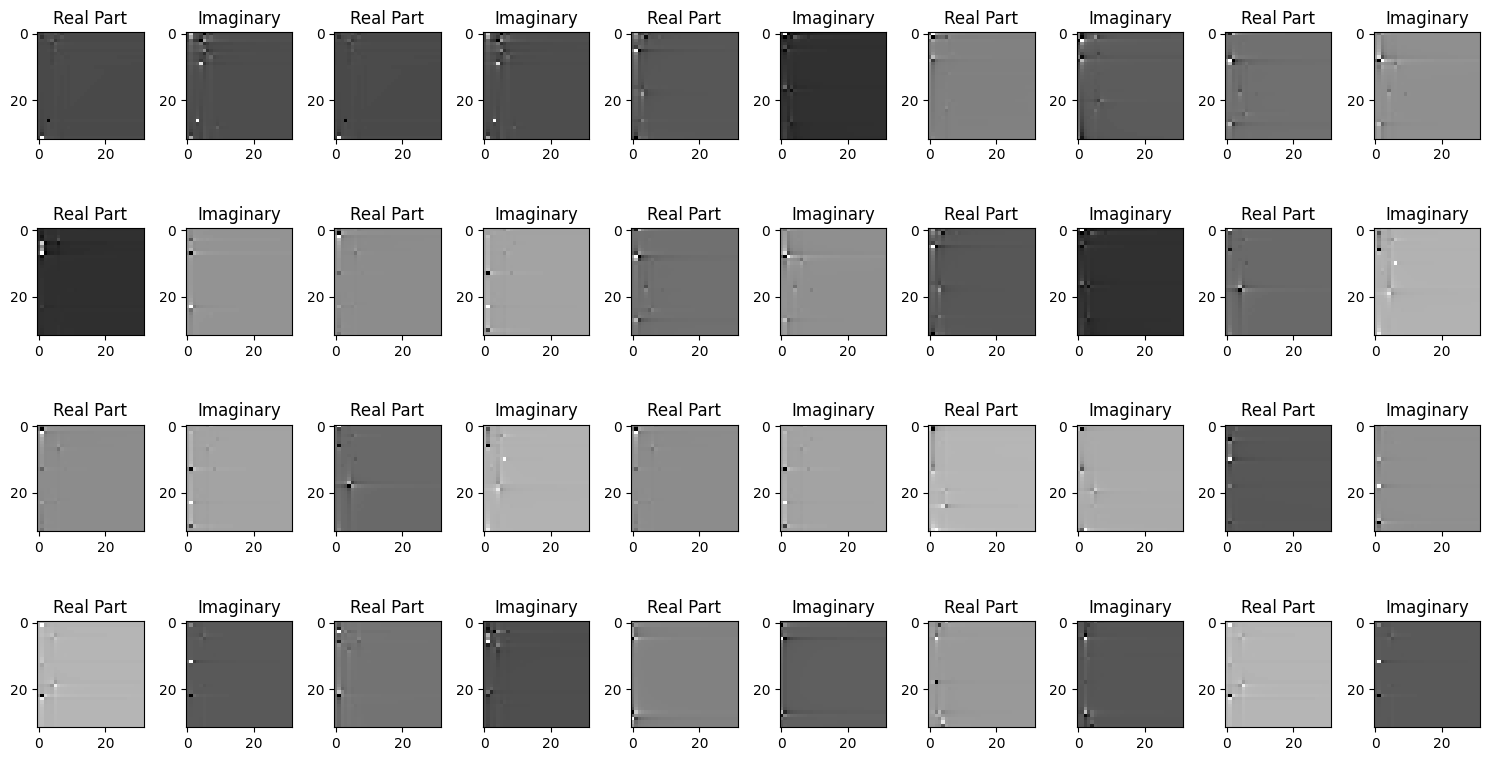

In [15]:
fig, axs = plt.subplots(4, 10, figsize=(15,8))
img_batch=x_train[200:220,:,:,:]

for i in range(0,10,2):
  for j in range(0,4):
    CSI_img = random.choice(img_batch)
    axs[j,i].imshow(np.array(CSI_img[0,:,:]), cmap='gist_gray')
    axs[j,i+1].imshow(np.array(CSI_img[1,:,:]), cmap='gist_gray')
    axs[j,i].set_title('Real Part')
    axs[j,i+1].set_title('Imaginary')
plt.tight_layout()

In [16]:
x_train = torch.tensor(x_train)
x_val = torch.tensor(x_val)
x_test = torch.tensor(x_test)
X_test = torch.tensor(X_test)

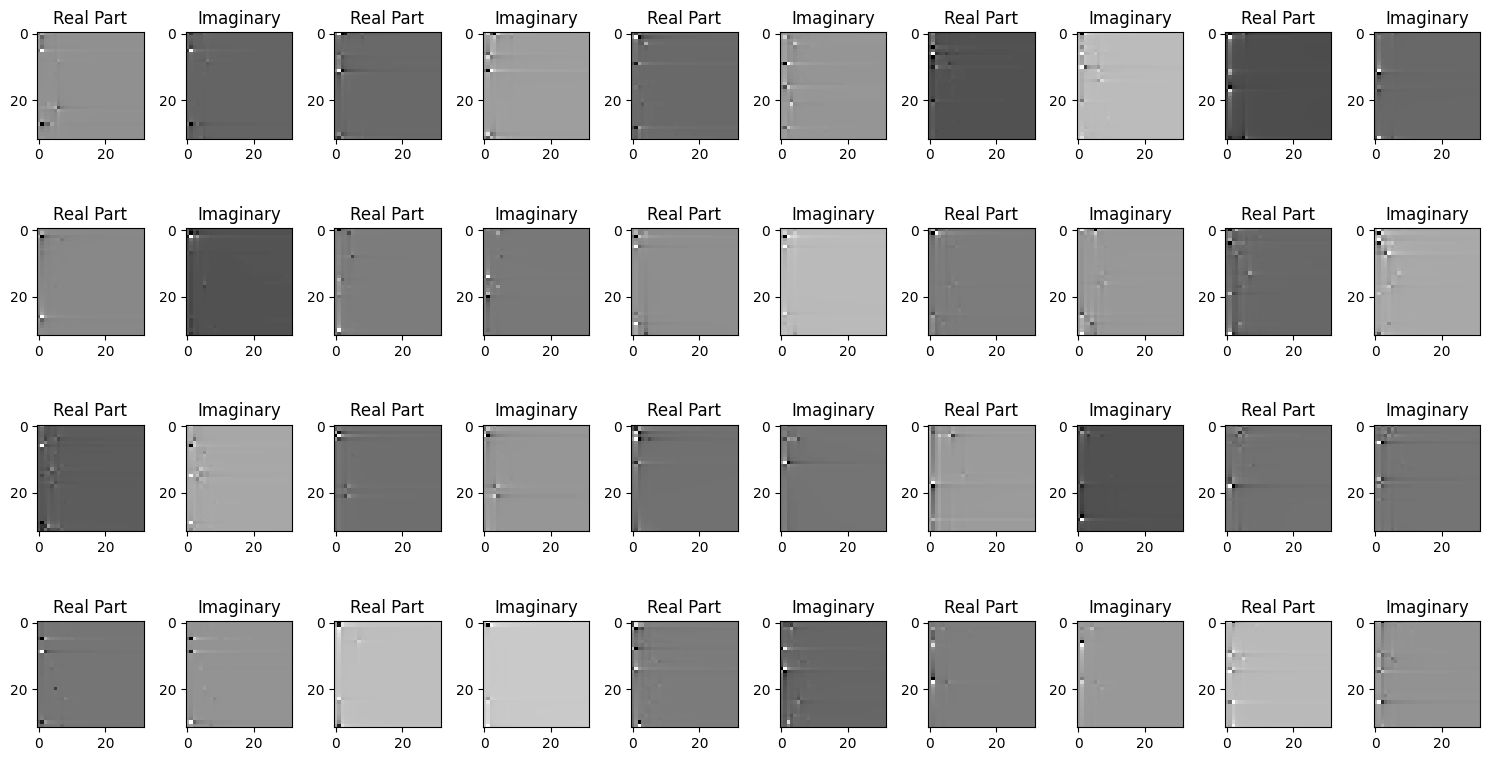

In [17]:
fig, axs = plt.subplots(4, 10, figsize=(15,8))
for i in range(0,10,2):
  for j in range(0,4):
    CSI_img = random.choice(x_train)
    axs[j,i].imshow(np.array(CSI_img[0,:,:]), cmap='gist_gray')
    axs[j,i+1].imshow(np.array(CSI_img[1,:,:]), cmap='gist_gray')
    axs[j,i].set_title('Real Part')
    axs[j,i+1].set_title('Imaginary')
plt.tight_layout()

In [18]:
# device
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(device)
x_train = x_train.to(device)
x_val = x_val.to(device)
x_test = x_test.to(device)
#noise=torch.randn((1,512)).to(device)


cuda


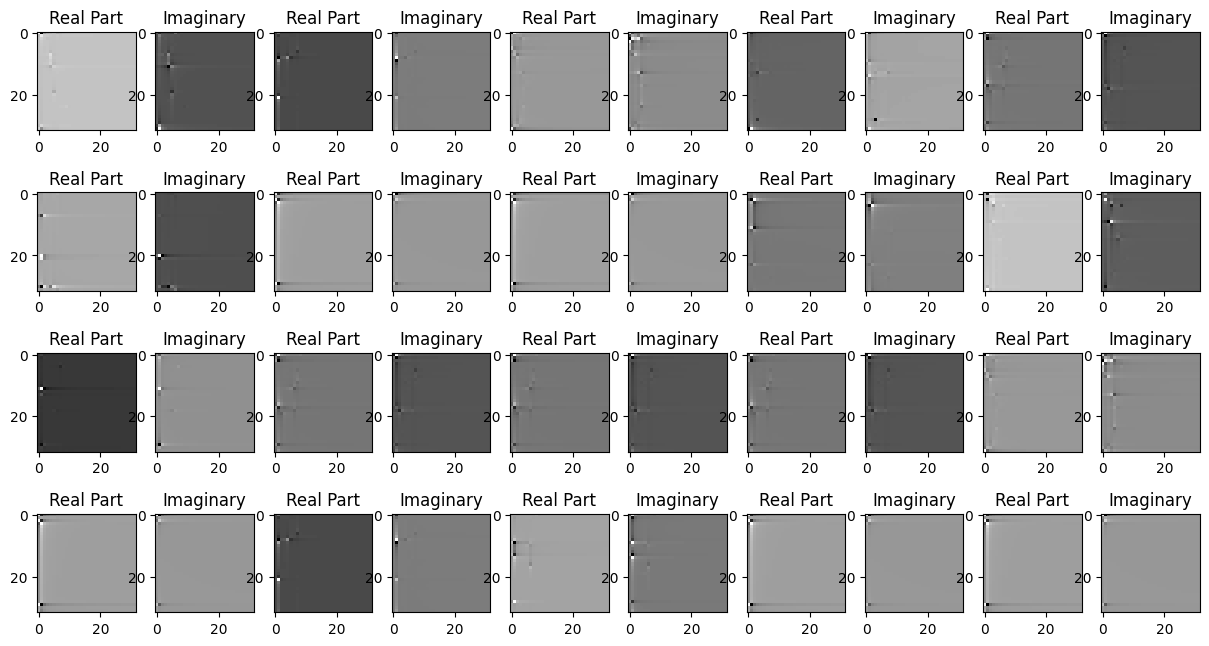

In [19]:
x_val_batch=x_val[0:20,:,:,:]
fig, axs = plt.subplots(4, 10, figsize=(15,8))
for i in range(0,10,2):
  for j in range(0,4):
    CSI_img = random.choice(x_val_batch.cpu())
    #print(CSI_img.shape)
    axs[j,i].imshow(np.array(CSI_img[0,:,:]), cmap='gist_gray')
    axs[j,i+1].imshow(np.array(CSI_img[1,:,:]), cmap='gist_gray')
    axs[j,i].set_title('Real Part')
    axs[j,i+1].set_title('Imaginary')
plt.show()

In [20]:
model = CLLWCsiNet().to(device)

torch.Size([5, 2, 32, 32])


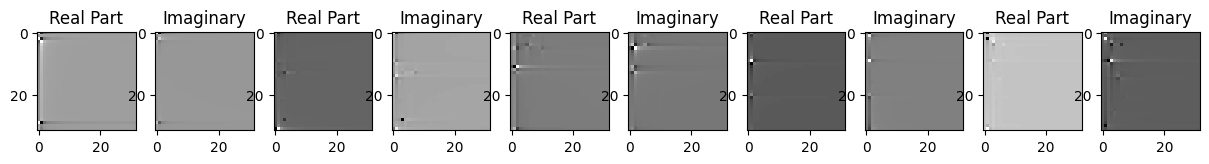

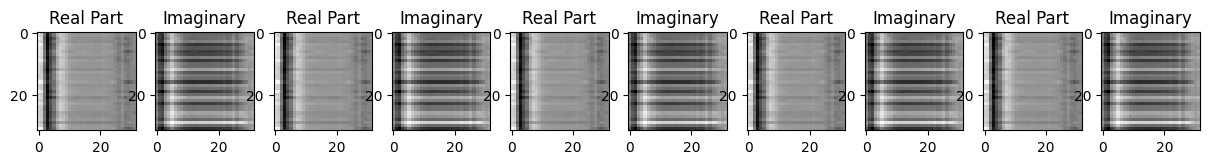

In [21]:
import itertools as it
with torch.no_grad():
  input=x_val[0:5,:,:,:]
  print(input.shape)
  model.eval()
  out = model(input)
  CSI_img_ = out.cpu()

  fig, axs = plt.subplots(1, 10, figsize=(15,8))
  for j, l in it.zip_longest(range(0, 5), range(1, 10,2)):
    in_img=input[j,0,:,:].cpu()
    axs[j*2].imshow(np.array(in_img.squeeze(0)), cmap='gist_gray')
    axs[j*2].set_title('Real Part')
    in_img=input[j,1,:,:].cpu()
    axs[l].imshow(np.array(in_img.squeeze(0)), cmap='gist_gray')
    axs[l].set_title('Imaginary')

  fig, axs = plt.subplots(1, 10, figsize=(15,8))
  for i, x in it.zip_longest(range(0, 5), range(1, 10,2)):

    #print(i)
    #CSI_img = random.choice(CSI_img_.cpu())
    img=CSI_img_[i,0,:,:]
    axs[i*2].imshow(np.array(img.squeeze(0)), cmap='gist_gray')
    axs[i*2].set_title('Real Part')
    img=CSI_img_[i,1,:,:]
    axs[x].imshow(np.array(img.squeeze(0)), cmap='gist_gray')
    axs[x].set_title('Imaginary')





  plt.show()

In [22]:
optimizer = optim.Adam(model.parameters(), lr=0.001, eps=1e-07)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)

In [28]:
# Define a log directory with a timestamp (to avoid overwriting)
import datetime
log_dir = "runs/experiment_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

In [23]:
# loss function
criterion = nn.MSELoss()

n_epochs = 501
batch_size = 200
total_batches = int(x_train_length/batch_size)

tStart = time.time()

train_loss_history = []
val_loss_history = []

In [24]:
encoded_dim = 256

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/_model_150_indoor_256_10x.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['lr_state_dict'])
start_epoch = checkpoint['epoch']

In [25]:

x_val=x_val[0:10000,:,:,:]

x_val_1=x_val = x_val.to(device)

In [ ]:
#epoch=550
with torch.autograd.set_detect_anomaly(True):
  for epoch in range(n_epochs):
      print('Epoch-{0} lr: {1}'.format(epoch, optimizer.param_groups[0]['lr']))
      for i in range(total_batches):
          x_batch = x_train[i*batch_size:(i+1)*batch_size,]
          #print(i*batch_size,(i+1)*batch_size)

          # criterion = nn.MSELoss()
          # model.to(device)
          # optimizer = optim.Adam(model.parameters(), lr=0.001, eps=1e-07)
          # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)


          model.train()

          out = model(x_batch)

          loss = criterion(out, x_batch)
          train_loss_history.append(loss.item())
          loss.backward()

          optimizer.step()
          optimizer.zero_grad()

      scheduler.step()

      # Validating
      with torch.no_grad():
          model.eval()

          out = model(x_val)
          loss = criterion(out, x_val)
          print("Loss: ",loss.item())
          val_loss_history.append(loss.item())



      with torch.no_grad():
        input=x_val[0:5,:,:,:]
        print(input.shape)
        model.eval()
        out = model(input)
        CSI_img_ = out.cpu()


        fig, axs = plt.subplots(1, 10, figsize=(15,8))
        for j, l in it.zip_longest(range(0, 5), range(1, 10,2)):
          in_img=input[j,0,:,:].cpu()
          axs[j*2].imshow(np.array(in_img.squeeze(0)), cmap='gist_gray')
          axs[j*2].set_title('Real Part')
          in_img=input[j,1,:,:].cpu()
          axs[l].imshow(np.array(in_img.squeeze(0)), cmap='gist_gray')
          axs[l].set_title('Imaginary')

        fig, axs = plt.subplots(1, 10, figsize=(15,8))
        for i, x in it.zip_longest(range(0, 5), range(1, 10,2)):

          #print(i)
          #CSI_img = random.choice(CSI_img_.cpu())
          img=CSI_img_[i,0,:,:]
          axs[i*2].imshow(np.array(img.squeeze(0)), cmap='gist_gray')
          axs[i*2].set_title('Real Part')
          img=CSI_img_[i,1,:,:]
          axs[x].imshow(np.array(img.squeeze(0)), cmap='gist_gray')
          axs[x].set_title('Imaginary')

        plt.show()


        if (epoch)%50==0:
          MODEL_PATH = Path("/kaggle/working/saved_model")
          MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                          exist_ok=True # if models directory already exists, don't error
          )


          # Create model save path
          MODEL_NAME = "CLLWCsiNet_model_{}_{}_{}_1x.pth".format(epoch,envir,encoded_dim)
          MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

          # Save the model state dict
          print(f"Saving model to: {MODEL_SAVE_PATH}")
          torch.save({'epoch': epoch,'model_state_dict': model.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                      'lr_state_dict': scheduler.state_dict()}, # only saving the state_dict() only saves the learned parameters
                      f=MODEL_SAVE_PATH)

        #if epoch%50==0:
        with torch.no_grad():
            model.eval()
            x_hat = model(x_test)
            x_test = x_test.to(device)
            x_hat=x_hat.to(device)
            X_test = torch.reshape(X_test, (len(X_test), img_height, 125))
            x_test_real = torch.reshape(x_test[:, 0, :, :], (len(x_test), -1))
            x_test_imag = torch.reshape(x_test[:, 1, :, :], (len(x_test), -1))
            x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)
            x_hat_real = torch.reshape(x_hat[:, 0, :, :], (len(x_hat), -1))
            x_hat_imag = torch.reshape(x_hat[:, 1, :, :], (len(x_hat), -1))
            x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)
            x_hat_F = torch.reshape(x_hat_C, (len(x_hat_C), img_height, img_width))
            X_hat = torch.fft.fft(torch.cat((x_hat_F, torch.zeros((len(x_hat_C), img_height, 257 - img_width)).to(device)), axis=2), axis=2)
            X_hat = X_hat[:, :, 0:125]

            n1 = torch.sqrt(torch.sum(torch.conj(X_test) * X_test, axis=1)).to(device)
            n2 = torch.sqrt(torch.sum(torch.conj(X_hat) * X_hat, axis=1)).to(device)
            aa = abs(torch.sum(torch.conj(X_test.to(device)) * X_hat, axis=1).to(device)).to(device)
            rho = torch.mean(aa / (n1 * n2), axis=1).to(device)
            X_hat = torch.reshape(X_hat, (len(X_hat), -1))
            X_test = torch.reshape(X_test, (len(X_test), -1))
            power = torch.sum(abs(x_test_C) ** 2, axis=1).to(device)
            power_d = torch.sum(abs(X_hat) ** 2, axis=1).to(device)
            mse = torch.sum(abs(x_test_C - x_hat_C) ** 2, axis=1).to(device)
            NMSE = 10 * math.log10(torch.mean(mse / power))
            Correlation = torch.mean(rho).item().real

            print("In " + envir + " environment")
            print("When dimension is", encoded_dim)
            print("NMSE is ", NMSE)
            print("Correlation is ", Correlation)

      #   import mysql.connector as mysql
      #   db = mysql.connect(
      #   host = "p3nlmysql165plsk.secureserver.net",
      #   user = "Hamide",
      #   passwd = "Vmkw788^6",
      #   database="Sale_find_customer"
      #  )


      #   mycursor = db.cursor()

      #   sql = "INSERT INTO paper_report	(Network_name, epocn_number,Val_loss,NMSE,Correlation,Status,operation_status	) VALUES (%s, %s,%s,%s,%s,%s,%s)"
      #   #val = ("ACRNET_10x_128_outdoor",'{}'.format(epoch+1),'{}'.format(loss.item()), '{}'.format(NMSE),'{}'.format(Correlation), "outdoor","live")
      #   val = ("َACRDNet_1x_512_indoor",'{}'.format(epoch),'{}'.format(loss.item()), '{}'.format(NMSE),'{}'.format(Correlation), "indoor","live")
      #   mycursor.execute(sql, val)

      #   db.commit()

      #   print(mycursor.rowcount, "record inserted.")









tEnd = time.time()
training_time = tEnd - tStart
print("It cost %f sec for training." % training_time)

Epoch-0 lr: 0.001
Validation MSE Loss: 0.0005113498773425817
In indoor environment
When dimension is 256
NMSE is  0.48735630550092535
Correlation is  0.15021738409996033
Saving model to: /kaggle/working/saved_model/CLLWCsiNet_model_0_indoor_256_1x.pth


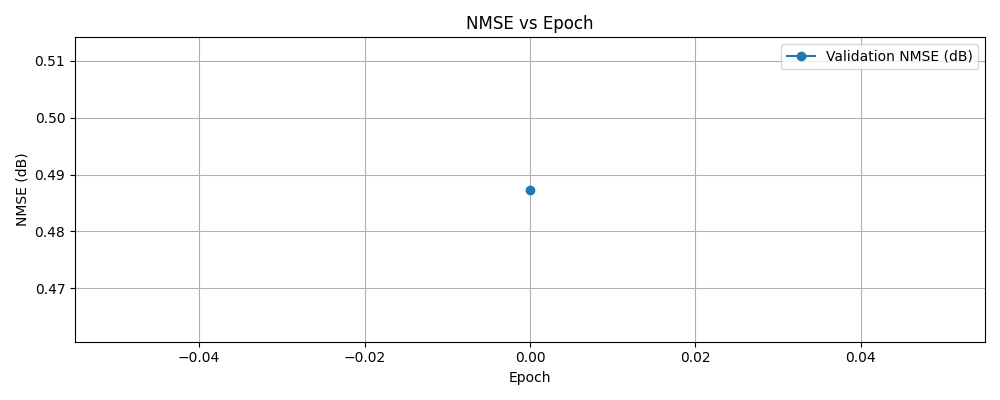

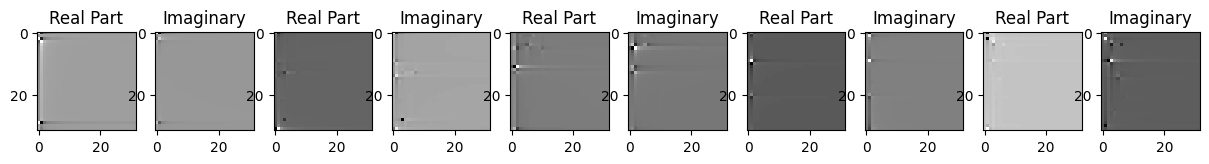

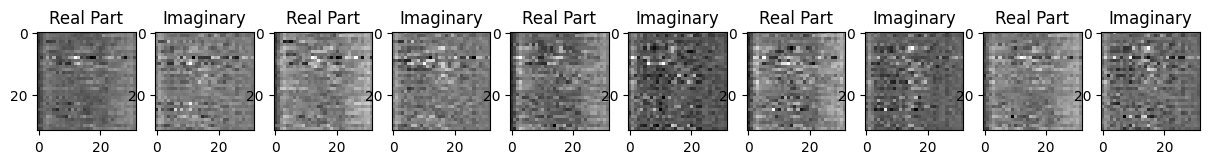

Epoch-1 lr: 0.001
Validation MSE Loss: 0.0004839527537114918
In indoor environment
When dimension is 256
NMSE is  0.27263335979215675
Correlation is  0.1649148166179657


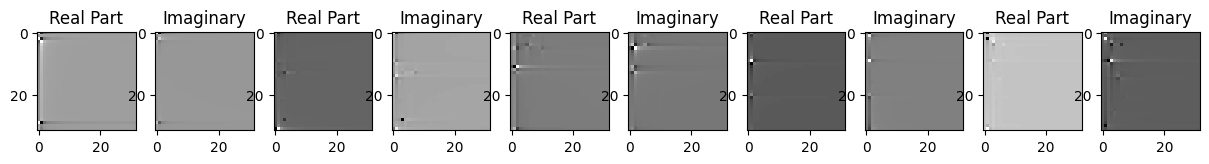

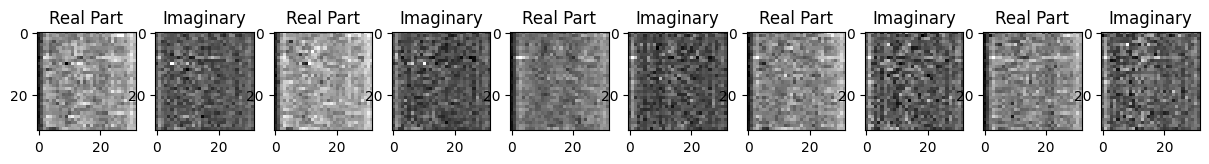

Epoch-2 lr: 0.001
Validation MSE Loss: 0.0004811736580450088
In indoor environment
When dimension is 256
NMSE is  0.2447488921583848
Correlation is  0.1678643822669983


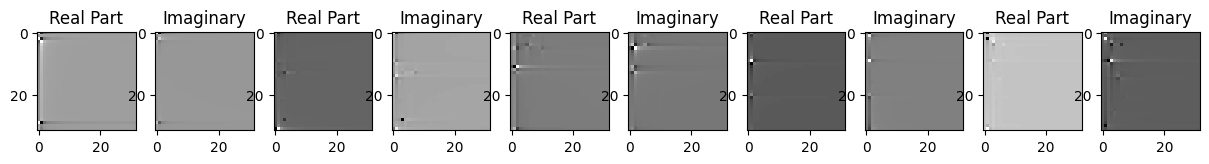

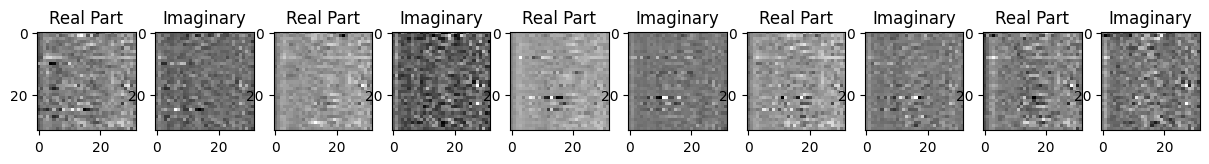

Epoch-3 lr: 0.001
Validation MSE Loss: 0.0004969778819940984
In indoor environment
When dimension is 256
NMSE is  0.3689478732656714
Correlation is  0.15377402305603027


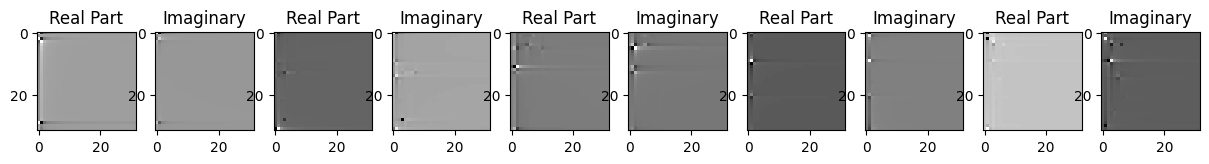

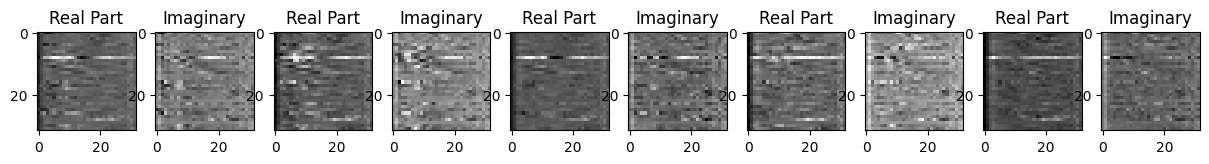

Epoch-4 lr: 0.001
Validation MSE Loss: 0.0004909989074803889
In indoor environment
When dimension is 256
NMSE is  0.4035167916997889
Correlation is  0.16158491373062134


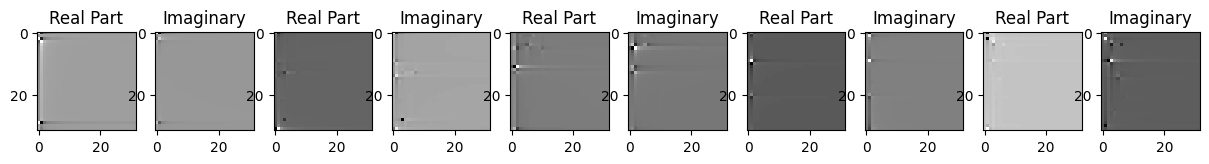

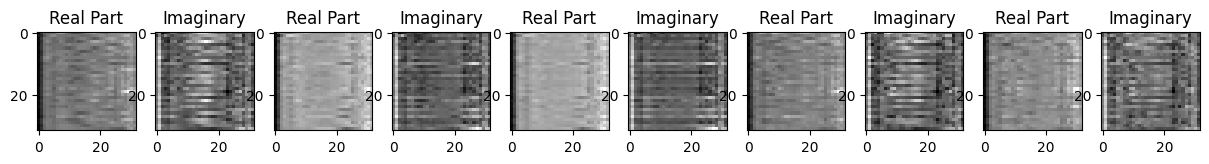

Epoch-5 lr: 0.001
Validation MSE Loss: 0.0005085380398668349
In indoor environment
When dimension is 256
NMSE is  0.5465758928734439
Correlation is  0.16325798630714417


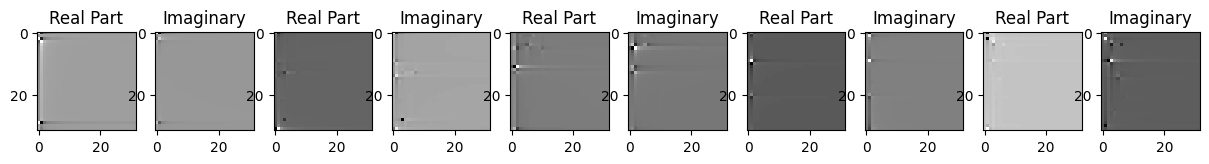

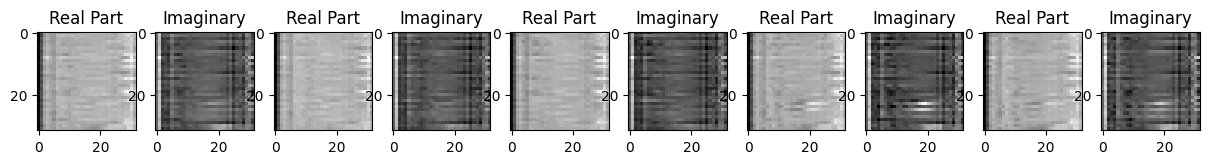

Epoch-6 lr: 0.001
Validation MSE Loss: 0.0004736676928587258
In indoor environment
When dimension is 256
NMSE is  0.1950352245637707
Correlation is  0.17586588859558105


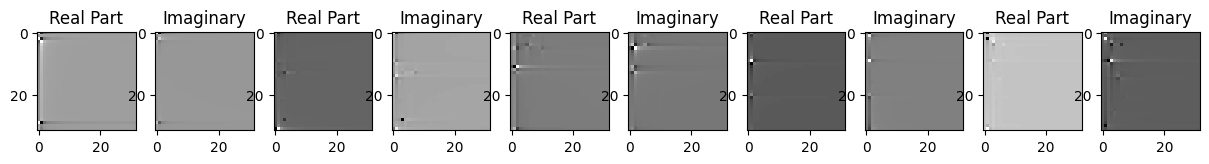

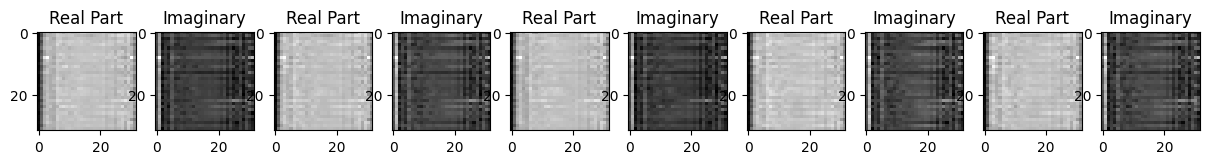

Epoch-7 lr: 0.001
Validation MSE Loss: 0.00047744836774654686
In indoor environment
When dimension is 256
NMSE is  0.2375514449556596
Correlation is  0.18068258464336395


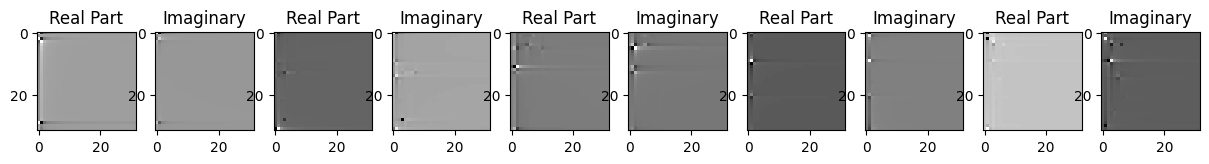

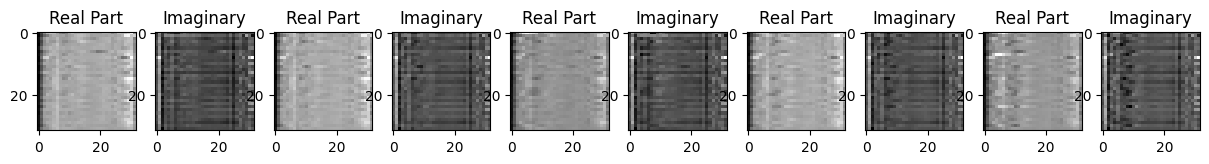

Epoch-8 lr: 0.001
Validation MSE Loss: 0.0004660235426854342
In indoor environment
When dimension is 256
NMSE is  0.13225881111806626
Correlation is  0.18412545323371887


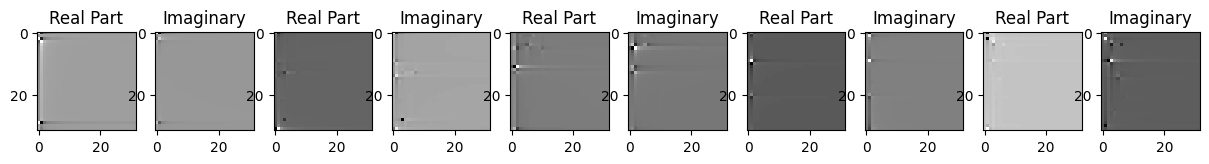

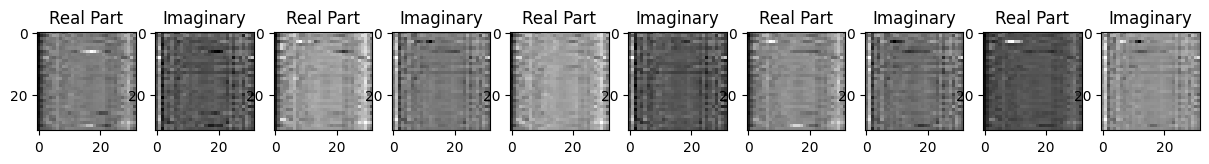

Epoch-9 lr: 0.001
Validation MSE Loss: 0.0004622600390575826
In indoor environment
When dimension is 256
NMSE is  0.10141801386095094
Correlation is  0.19702716171741486


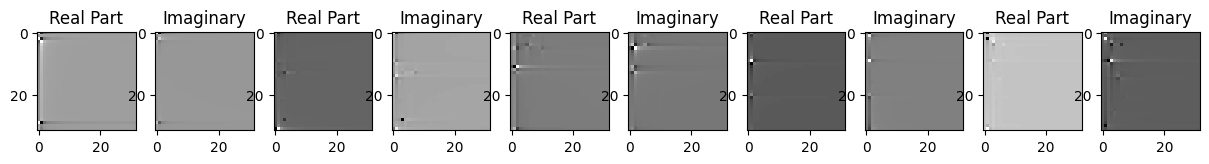

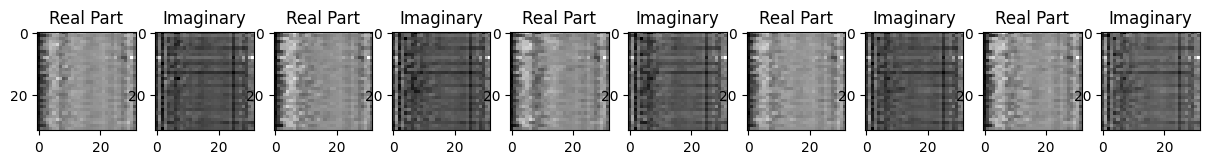

Epoch-10 lr: 0.001
Validation MSE Loss: 0.0004810150130651891
In indoor environment
When dimension is 256
NMSE is  0.23531377113381116
Correlation is  0.18777473270893097


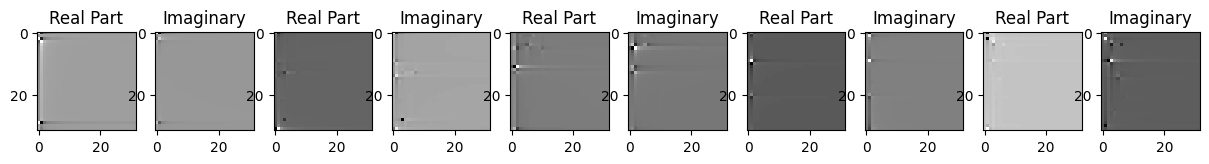

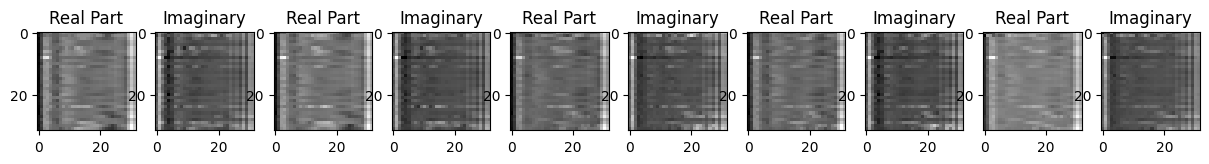

Epoch-13 lr: 0.001
Validation MSE Loss: 0.0004729295615106821
In indoor environment
When dimension is 256
NMSE is  0.1670982742347737
Correlation is  0.18794593214988708


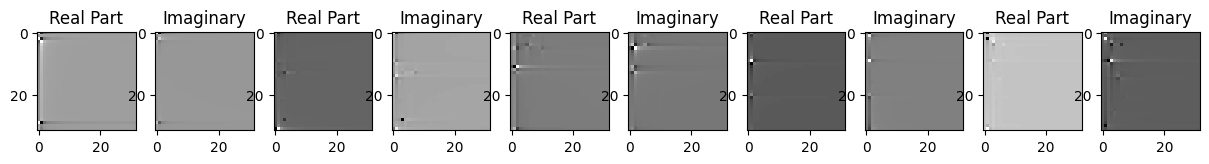

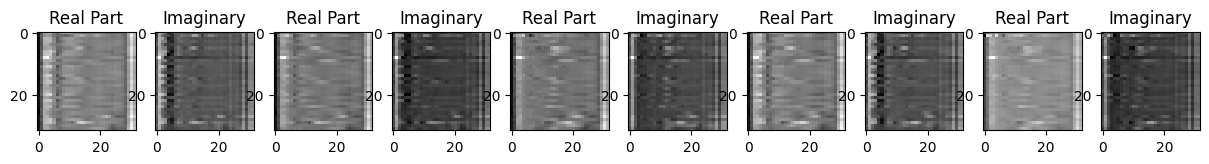

Epoch-14 lr: 0.001
Validation MSE Loss: 0.0004720880533568561
In indoor environment
When dimension is 256
NMSE is  0.15800947560677153
Correlation is  0.19095659255981445


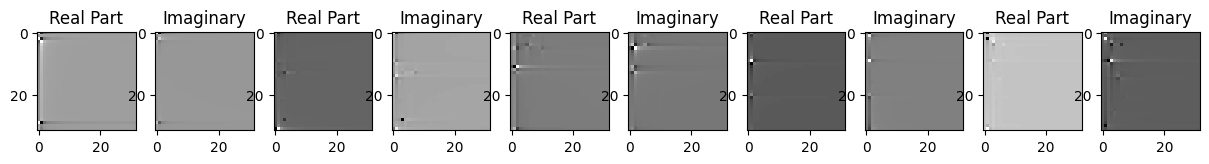

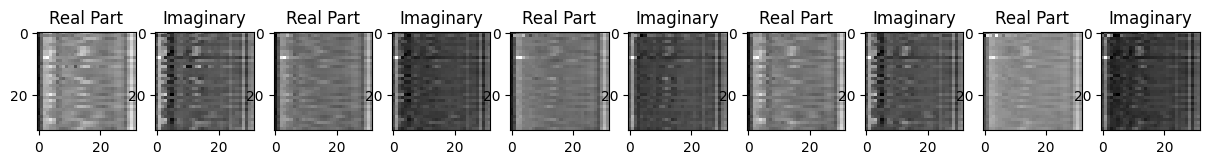

Epoch-15 lr: 0.001
Validation MSE Loss: 0.00047010587877593935
In indoor environment
When dimension is 256
NMSE is  0.13953798563107409
Correlation is  0.189952090382576


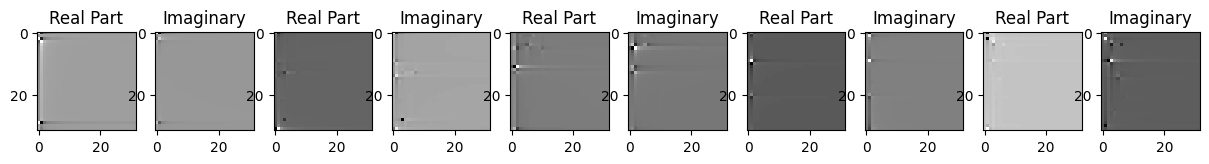

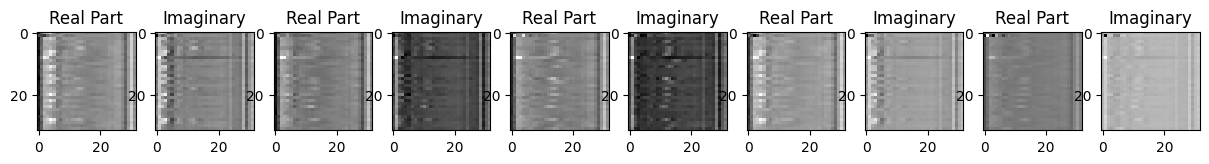

Epoch-16 lr: 0.001
Validation MSE Loss: 0.00047450297279283404
In indoor environment
When dimension is 256
NMSE is  0.17811892309680188
Correlation is  0.18148723244667053


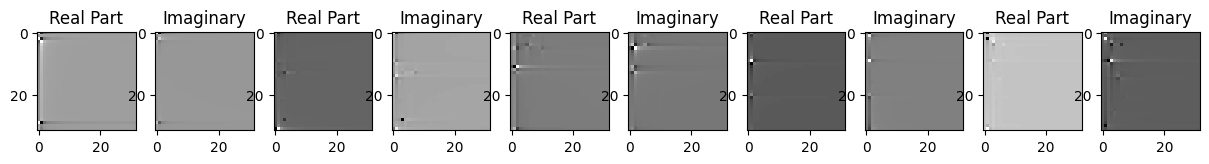

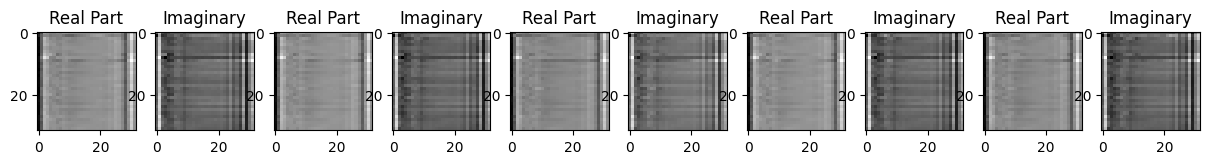

Epoch-17 lr: 0.001
Validation MSE Loss: 0.00046305544674396515
In indoor environment
When dimension is 256
NMSE is  0.08539911137936047
Correlation is  0.1915644109249115


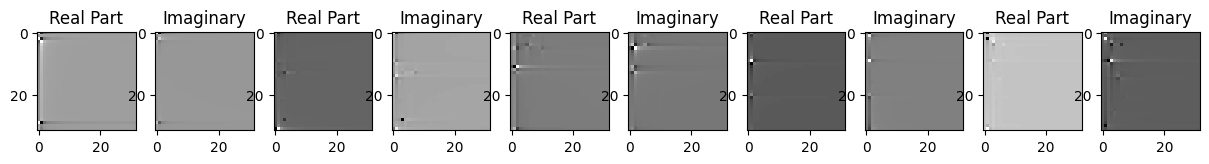

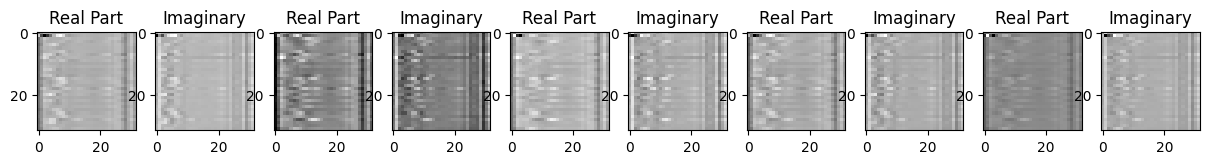

Epoch-18 lr: 0.001
Validation MSE Loss: 0.0004646445740945637
In indoor environment
When dimension is 256
NMSE is  0.09474989039957651
Correlation is  0.19863751530647278


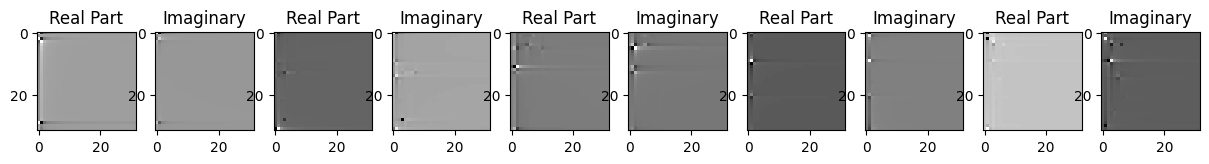

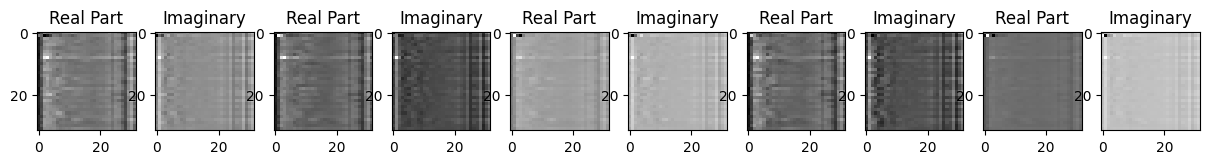

Epoch-19 lr: 0.001
Validation MSE Loss: 0.0004587824805639684
In indoor environment
When dimension is 256
NMSE is  0.052106795569364456
Correlation is  0.1936216801404953


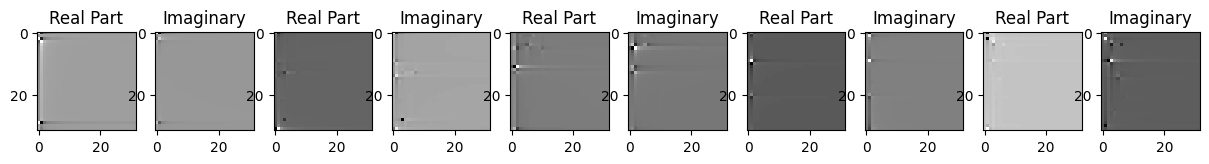

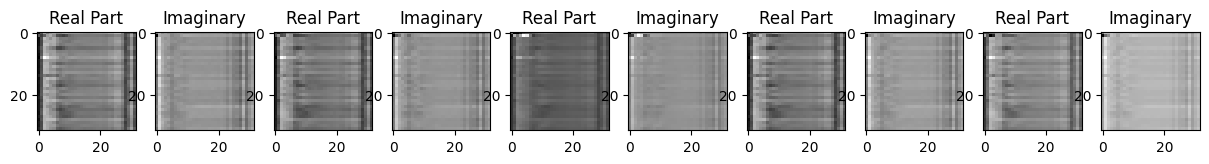

Epoch-20 lr: 0.001
Validation MSE Loss: 0.00045675114961341023
In indoor environment
When dimension is 256
NMSE is  0.03808524822158969
Correlation is  0.19508610665798187


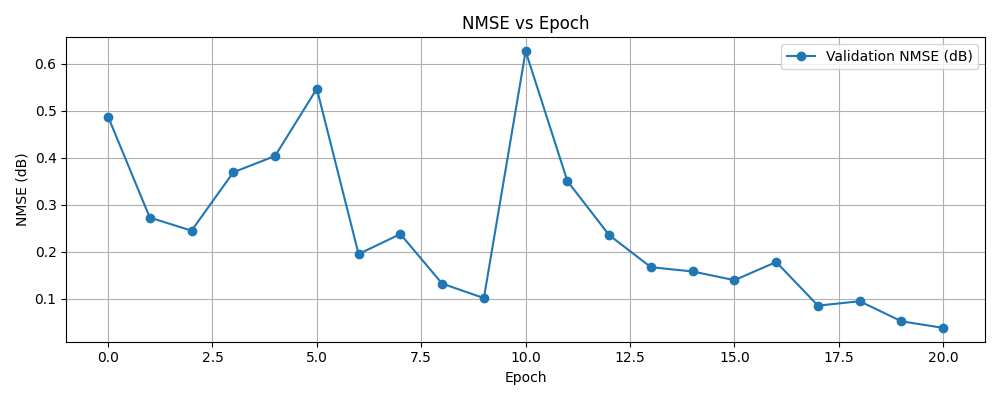

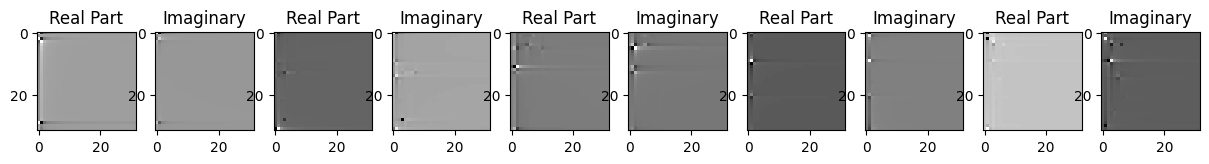

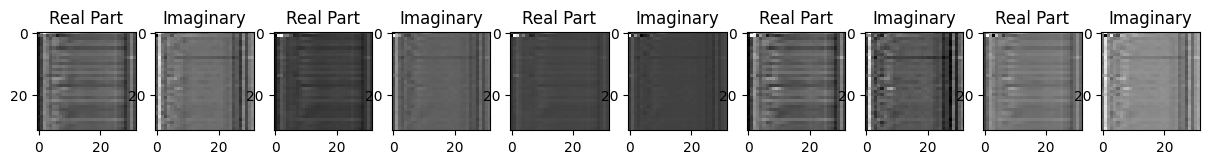

Epoch-21 lr: 0.001
Validation MSE Loss: 0.0004515647888183594
In indoor environment
When dimension is 256
NMSE is  -0.007222751859820189
Correlation is  0.19789044559001923


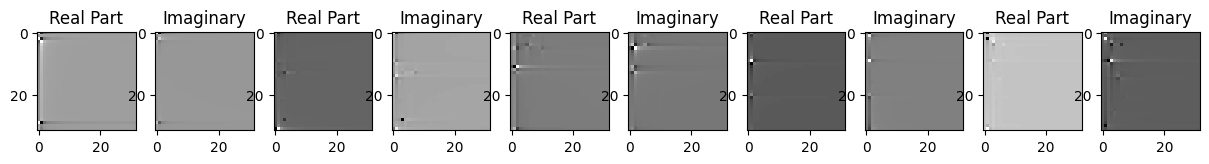

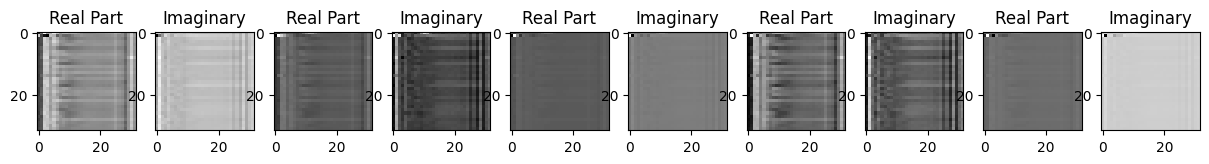

Epoch-22 lr: 0.001
Validation MSE Loss: 0.00047006766544654965
In indoor environment
When dimension is 256
NMSE is  0.16339124427515173
Correlation is  0.17569835484027863


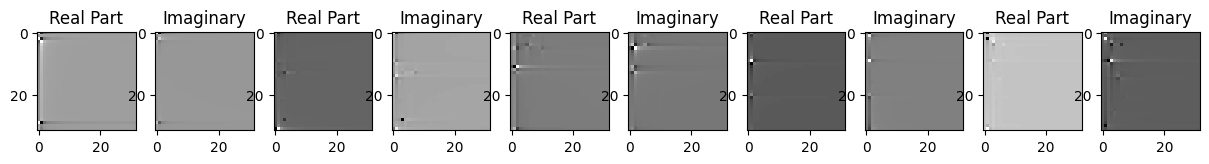

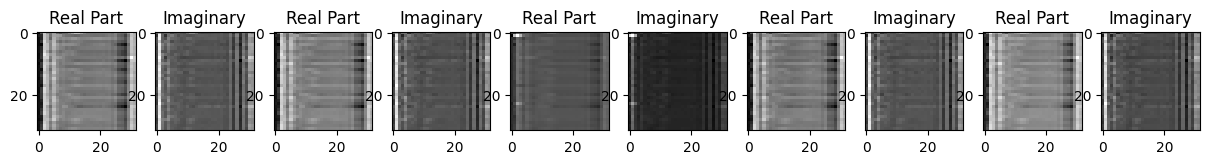

Epoch-23 lr: 0.001
Validation MSE Loss: 0.000456404872238636
In indoor environment
When dimension is 256
NMSE is  0.03597651444907098
Correlation is  0.19307224452495575


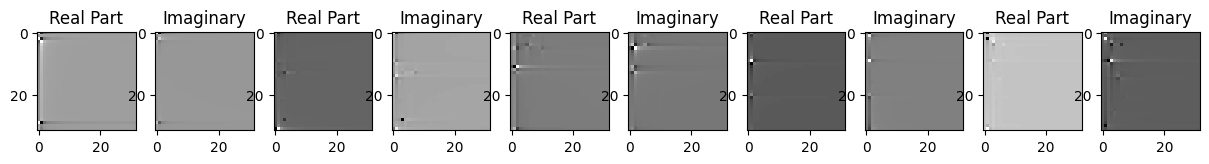

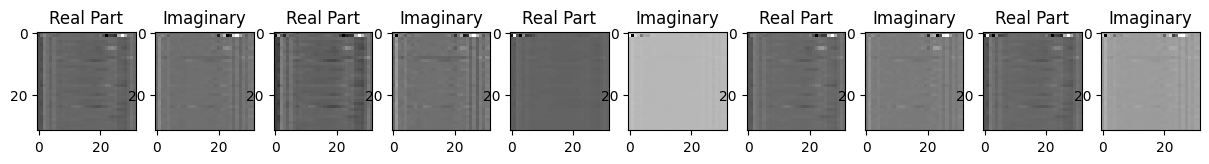

Epoch-24 lr: 0.001
Validation MSE Loss: 0.0004529155557975173
In indoor environment
When dimension is 256
NMSE is  0.0006393363560428208
Correlation is  0.19809021055698395


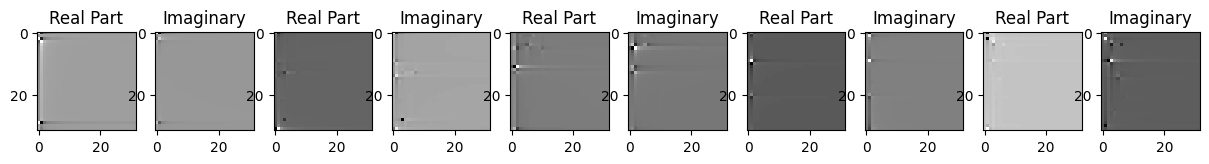

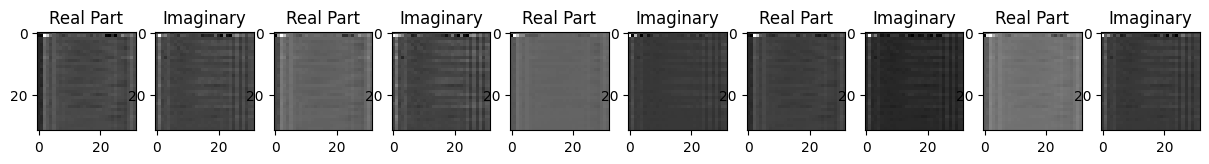

Epoch-25 lr: 0.001
Validation MSE Loss: 0.00044810393592342734
In indoor environment
When dimension is 256
NMSE is  -0.042726412632019914
Correlation is  0.21811352670192719


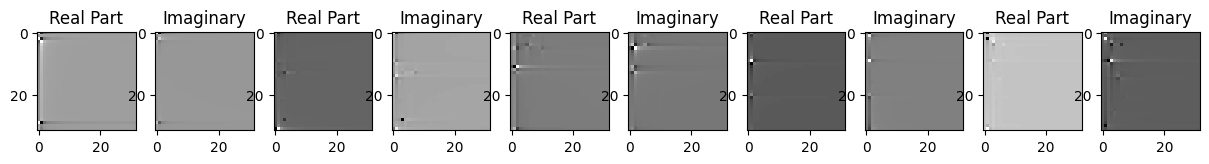

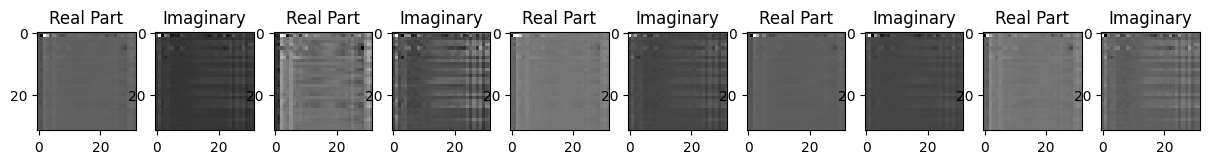

Epoch-26 lr: 0.001
Validation MSE Loss: 0.00044312223326414824
In indoor environment
When dimension is 256
NMSE is  -0.10423975174937872
Correlation is  0.28091368079185486


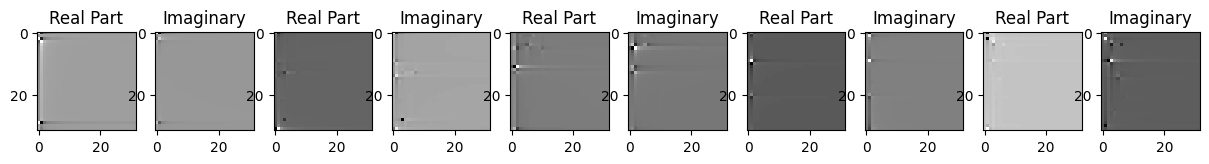

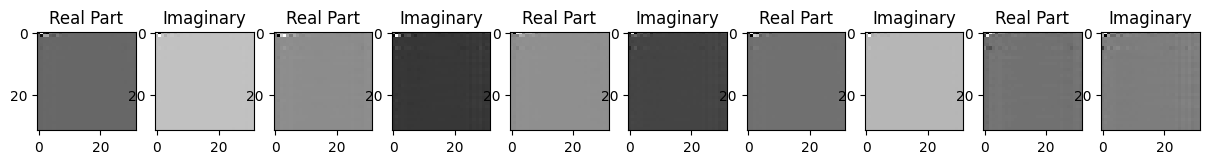

Epoch-27 lr: 0.001
Validation MSE Loss: 0.00043498401646502316
In indoor environment
When dimension is 256
NMSE is  -0.2068650937478848
Correlation is  0.3036121428012848


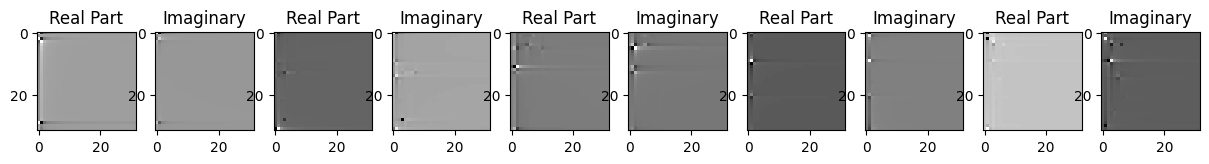

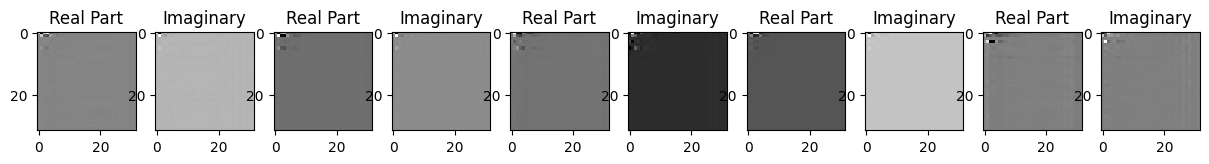

Epoch-28 lr: 0.001
Validation MSE Loss: 0.00041745867929421365
In indoor environment
When dimension is 256
NMSE is  -0.40037832354853653
Correlation is  0.3431435525417328


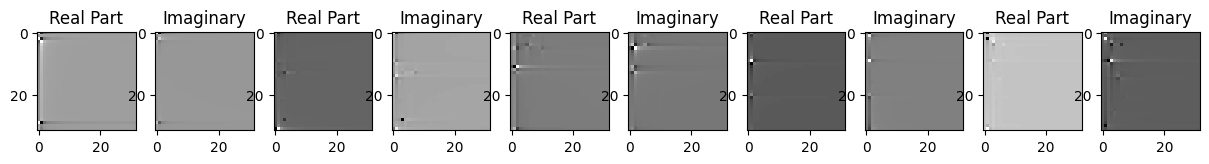

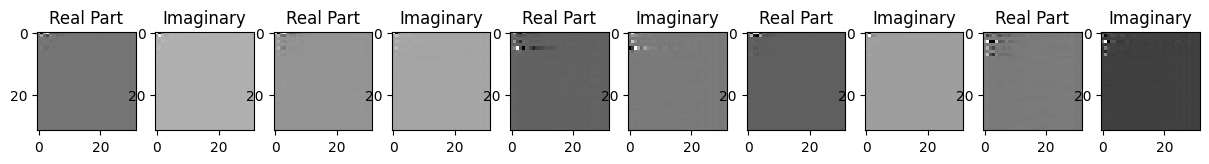

Epoch-29 lr: 0.001
Validation MSE Loss: 0.00039558601565659046
In indoor environment
When dimension is 256
NMSE is  -0.6379171220152138
Correlation is  0.4051350951194763


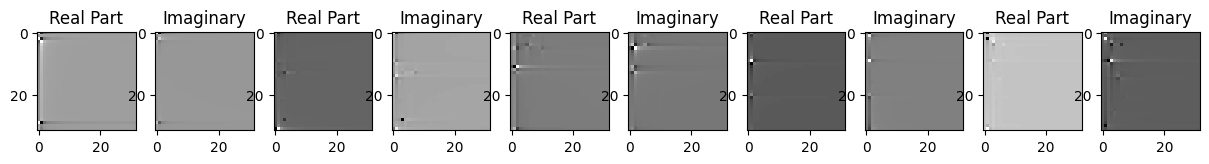

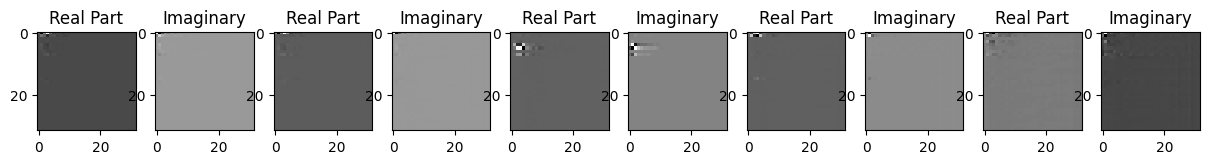

Epoch-30 lr: 0.001
Validation MSE Loss: 0.0003800686390604824
In indoor environment
When dimension is 256
NMSE is  -0.8200004740180944
Correlation is  0.44110584259033203


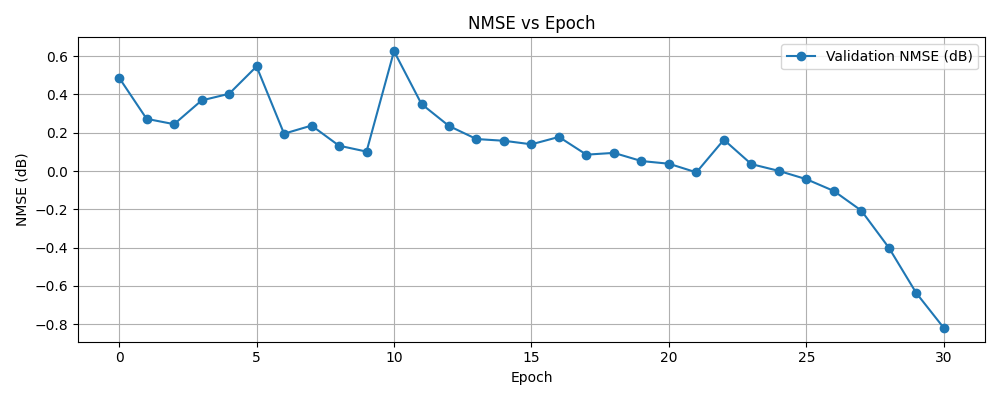

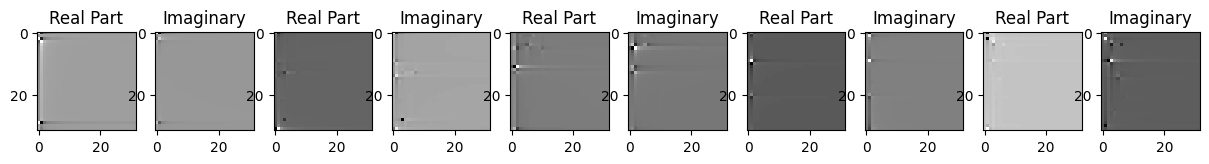

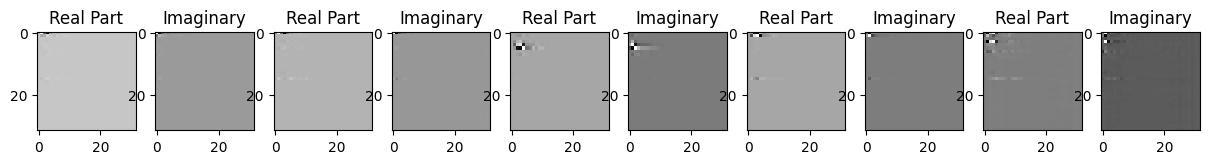

Epoch-31 lr: 0.001
Validation MSE Loss: 0.00036116933915764093
In indoor environment
When dimension is 256
NMSE is  -1.045804435696866
Correlation is  0.4863126873970032


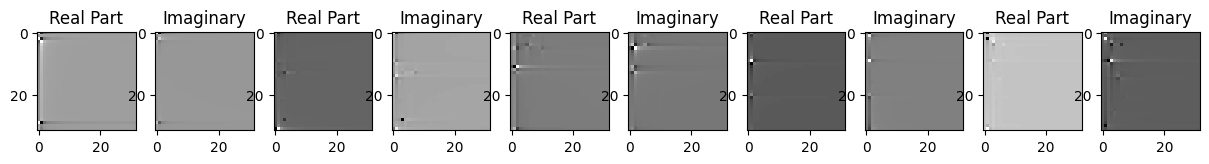

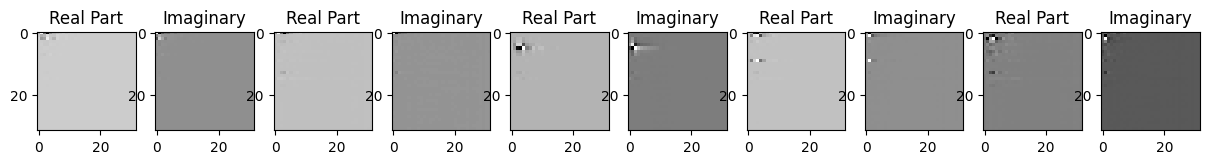

Epoch-32 lr: 0.001
Validation MSE Loss: 0.00034665988641791046
In indoor environment
When dimension is 256
NMSE is  -1.2276685582812639
Correlation is  0.515214741230011


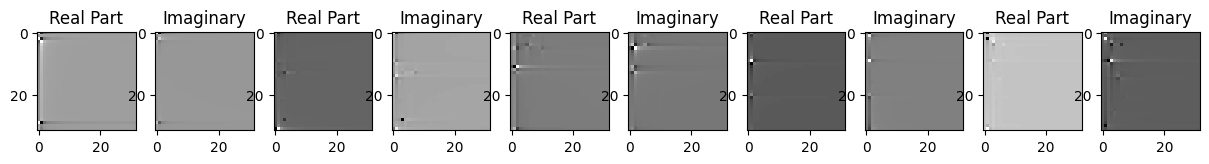

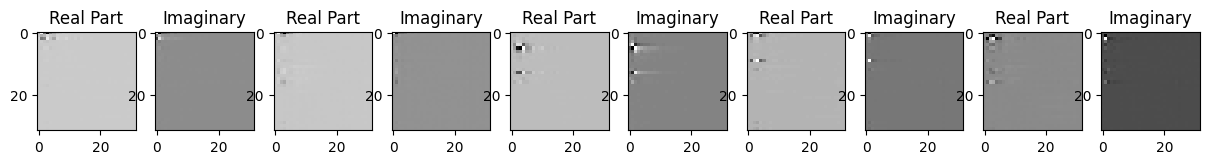

Epoch-33 lr: 0.001
Validation MSE Loss: 0.0003344688448123634
In indoor environment
When dimension is 256
NMSE is  -1.38574168250408
Correlation is  0.5384813547134399


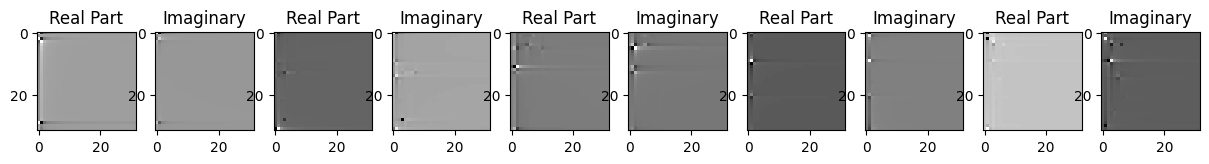

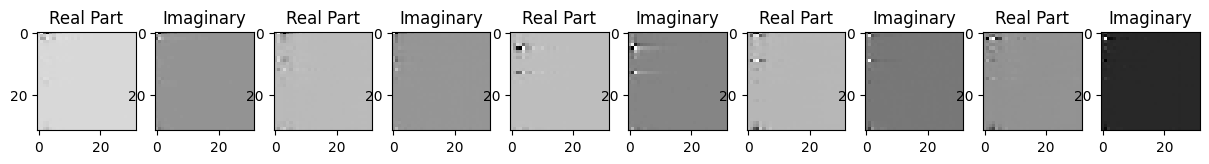

Epoch-34 lr: 0.001
Validation MSE Loss: 0.0003129086981061846
In indoor environment
When dimension is 256
NMSE is  -1.6750315032253233
Correlation is  0.5729790329933167


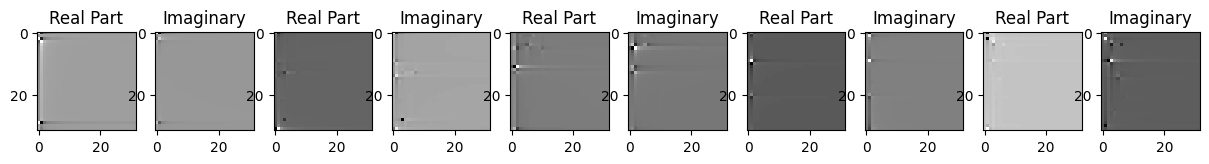

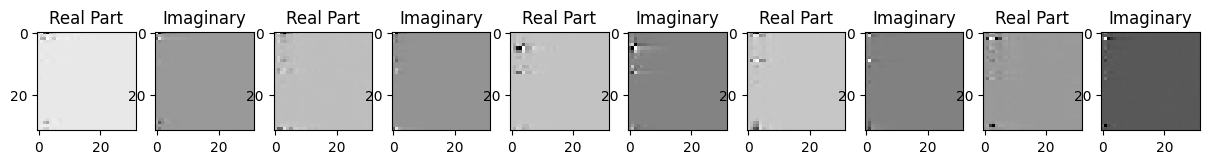

Epoch-35 lr: 0.001
Validation MSE Loss: 0.0003047458012588322
In indoor environment
When dimension is 256
NMSE is  -1.785477826415561
Correlation is  0.5833225250244141


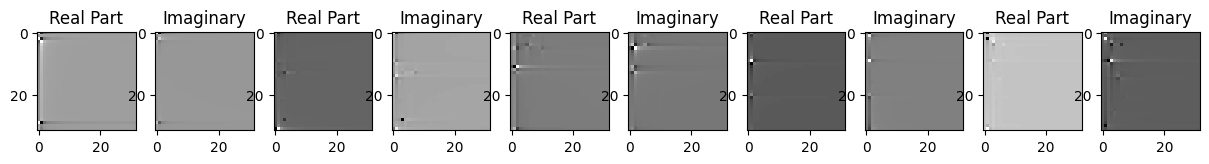

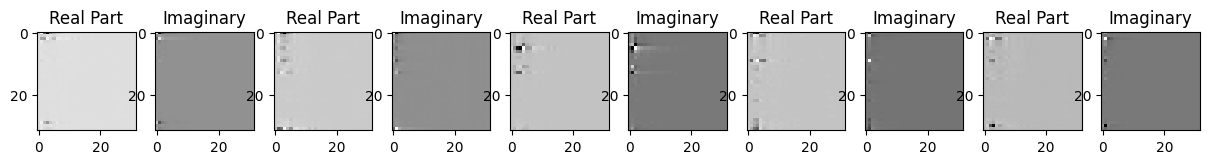

Epoch-36 lr: 0.001
Validation MSE Loss: 0.00029211892979219556
In indoor environment
When dimension is 256
NMSE is  -1.9686582097262242
Correlation is  0.6014337539672852


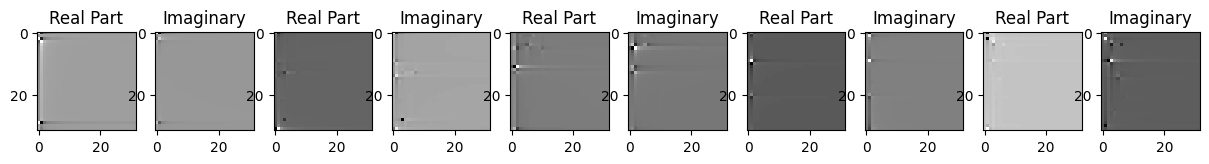

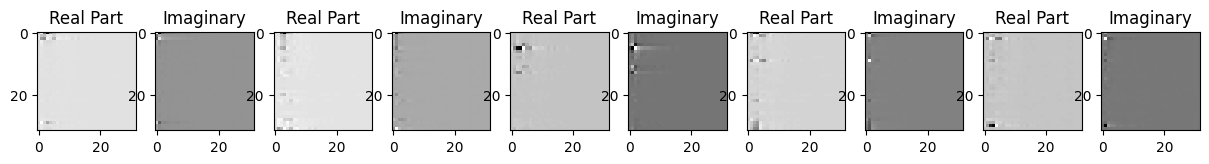

Epoch-37 lr: 0.001
Validation MSE Loss: 0.00027999148005619645
In indoor environment
When dimension is 256
NMSE is  -2.138885930236831
Correlation is  0.6154996752738953


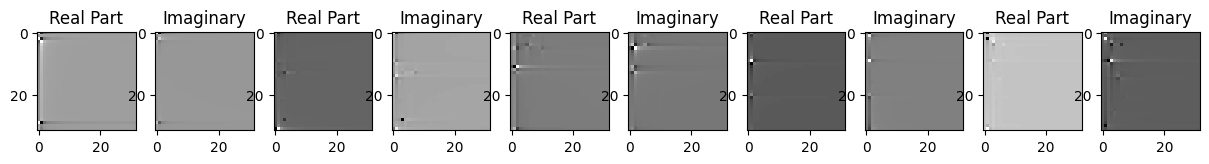

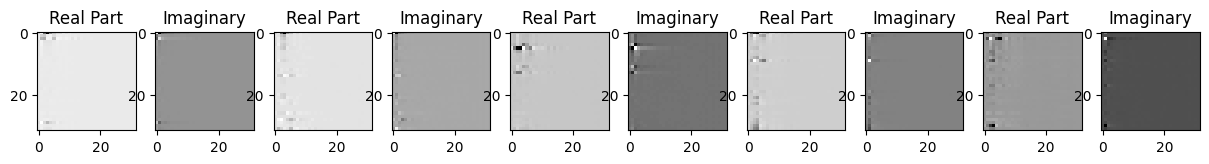

Epoch-38 lr: 0.001
Validation MSE Loss: 0.0002706230152398348
In indoor environment
When dimension is 256
NMSE is  -2.2781757827178146
Correlation is  0.6261003017425537


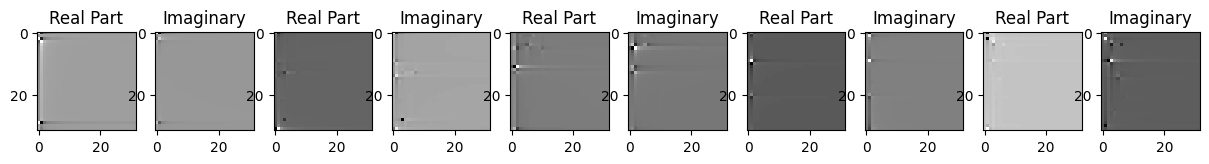

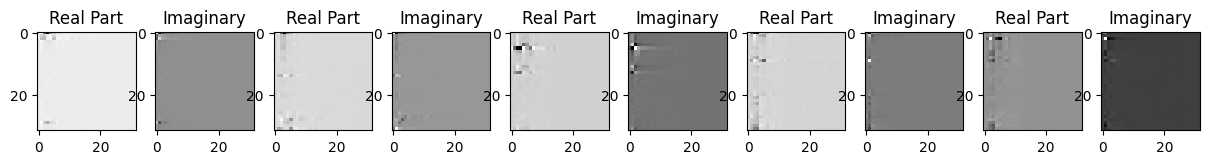

Epoch-39 lr: 0.001
Validation MSE Loss: 0.0002638567821122706
In indoor environment
When dimension is 256
NMSE is  -2.378460025508792
Correlation is  0.6329392790794373


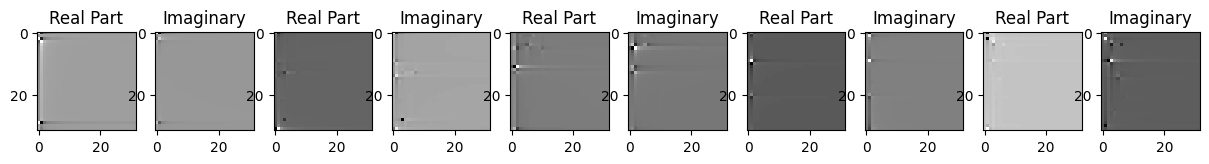

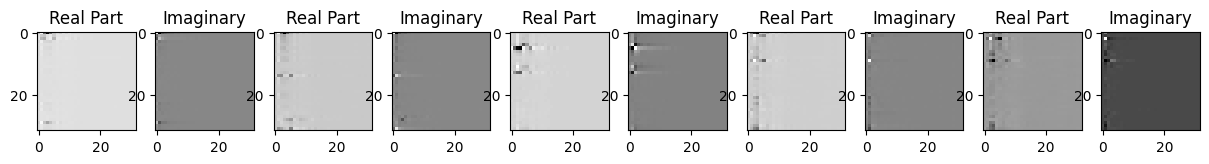

Epoch-40 lr: 0.001
Validation MSE Loss: 0.00026016758056357503
In indoor environment
When dimension is 256
NMSE is  -2.43424840757739
Correlation is  0.6362558007240295


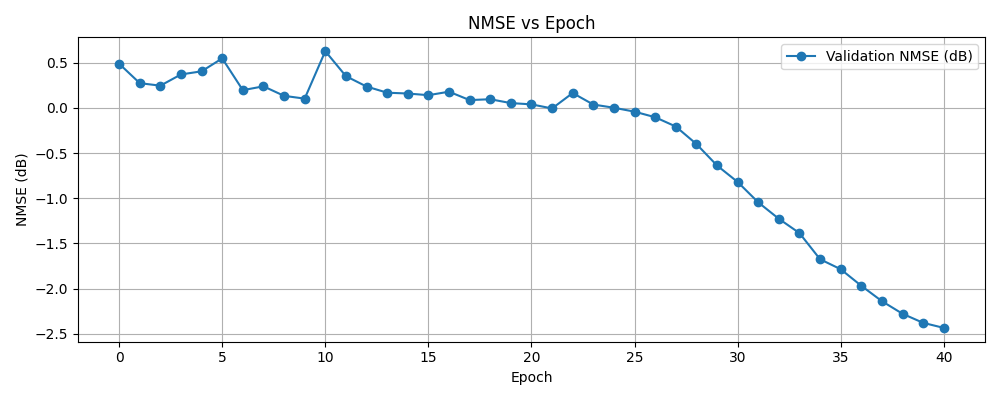

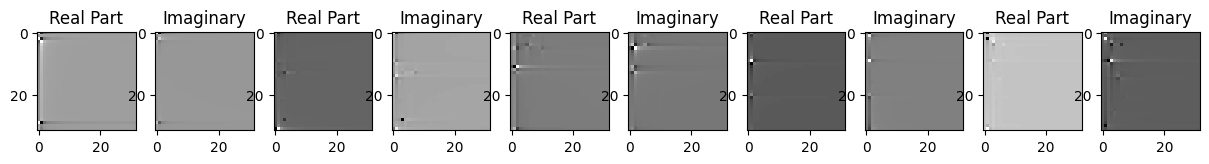

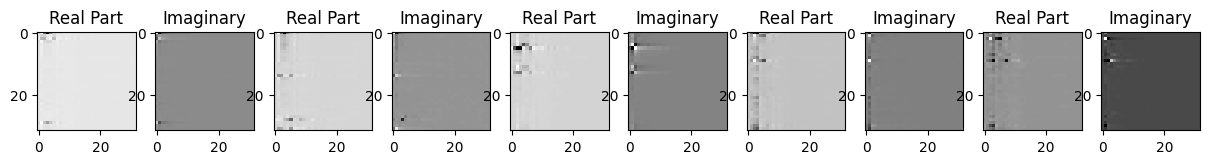

Epoch-41 lr: 0.001
Validation MSE Loss: 0.00025721429847180843
In indoor environment
When dimension is 256
NMSE is  -2.480536437771729
Correlation is  0.6387205719947815


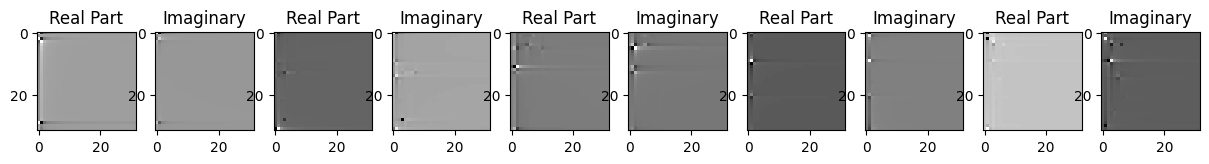

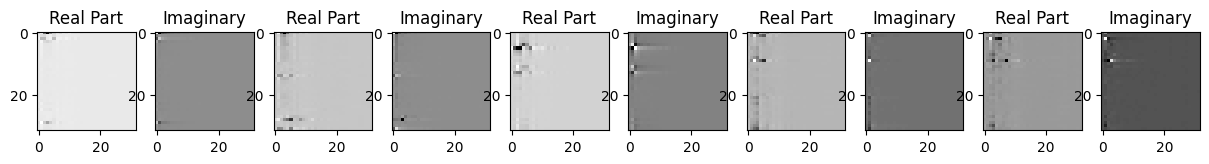

Epoch-42 lr: 0.001
Validation MSE Loss: 0.00025345172616653144
In indoor environment
When dimension is 256
NMSE is  -2.53832116026289
Correlation is  0.6405813097953796


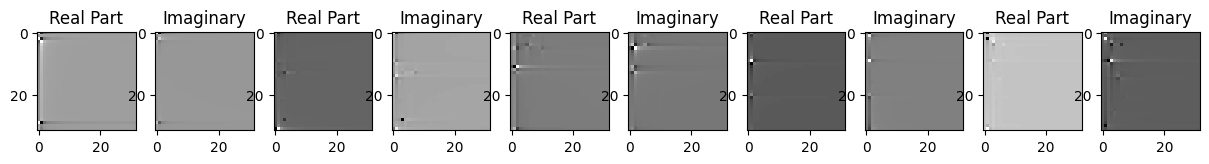

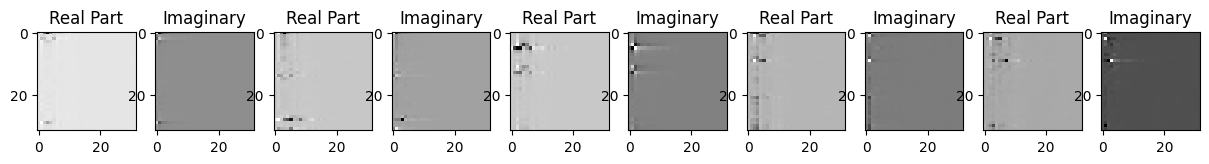

Epoch-44 lr: 0.001
Validation MSE Loss: 0.0002517701650504023
In indoor environment
When dimension is 256
NMSE is  -2.565656411950941
Correlation is  0.6415207982063293


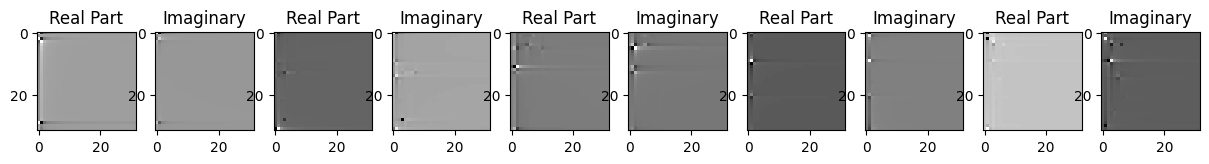

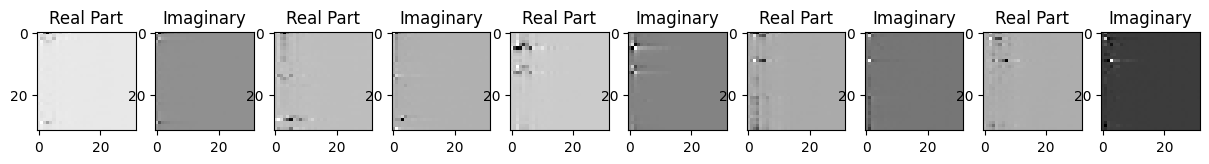

Epoch-45 lr: 0.001
Validation MSE Loss: 0.0002501982089597732
In indoor environment
When dimension is 256
NMSE is  -2.591642691770665
Correlation is  0.6428302526473999


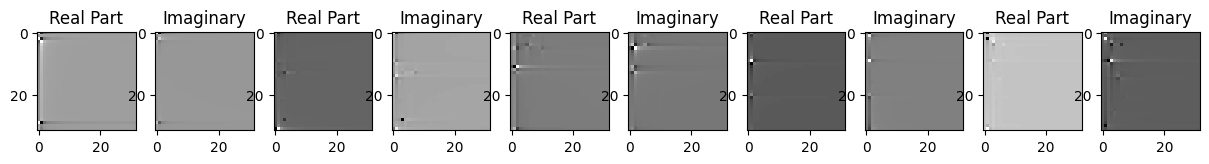

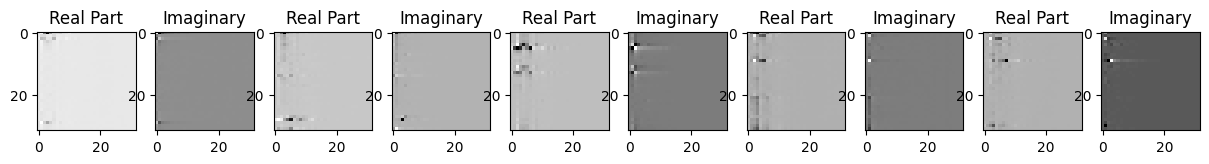

Epoch-46 lr: 0.001
Validation MSE Loss: 0.00024889325140975416
In indoor environment
When dimension is 256
NMSE is  -2.613258972858104
Correlation is  0.6439608335494995


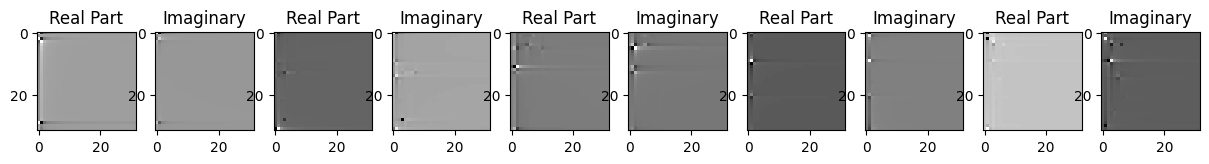

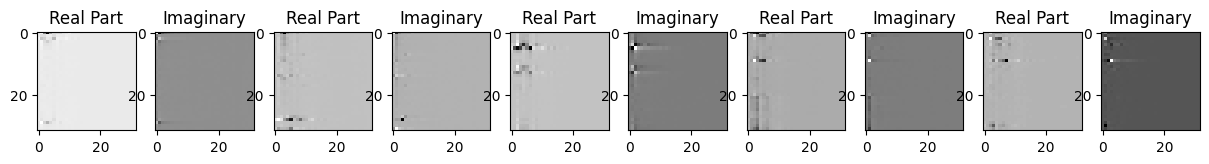

Epoch-47 lr: 0.001
Validation MSE Loss: 0.0002477710659150034
In indoor environment
When dimension is 256
NMSE is  -2.631433854812231
Correlation is  0.6447931528091431


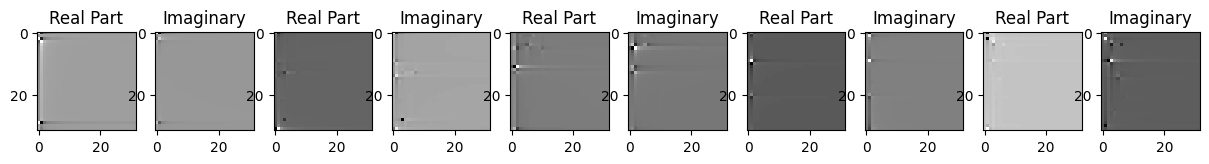

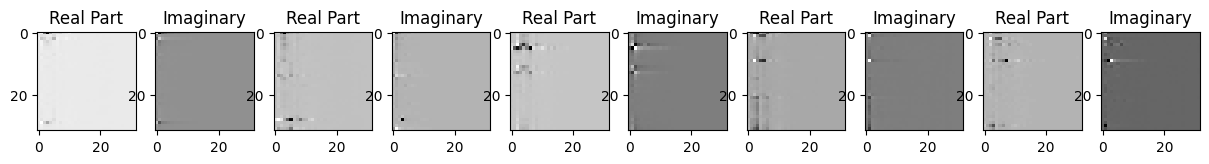

Epoch-48 lr: 0.001
Validation MSE Loss: 0.0002468371530994773
In indoor environment
When dimension is 256
NMSE is  -2.646869156548983
Correlation is  0.6458355188369751


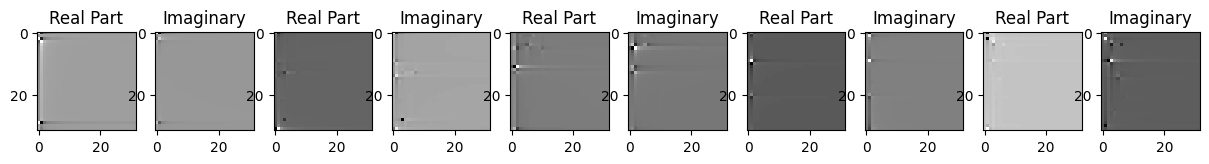

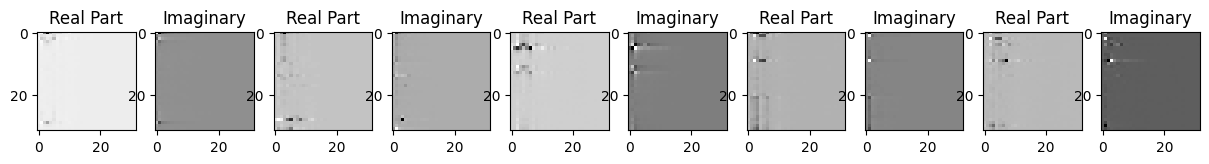

Epoch-49 lr: 0.001
Validation MSE Loss: 0.00024471222423017025
In indoor environment
When dimension is 256
NMSE is  -2.679681540518257
Correlation is  0.647165060043335


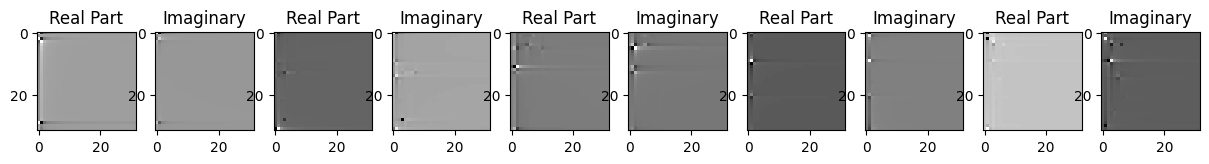

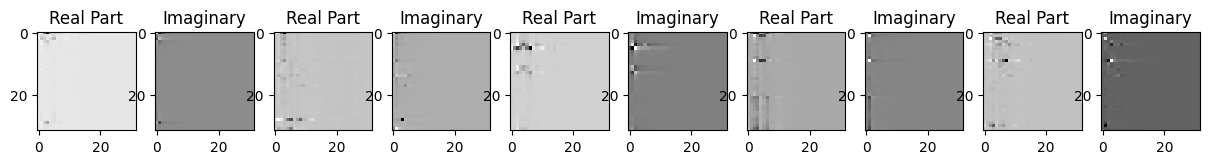

Epoch-52 lr: 0.001
Validation MSE Loss: 0.00024399952962994576
In indoor environment
When dimension is 256
NMSE is  -2.692622912874336
Correlation is  0.6477639675140381


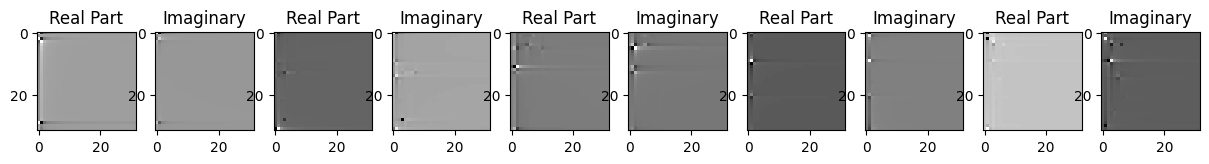

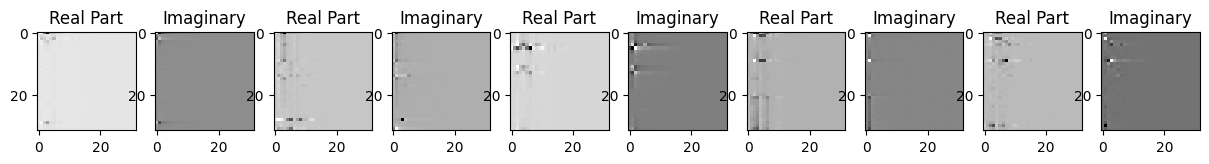

Epoch-53 lr: 0.001
Validation MSE Loss: 0.00024356221547350287
In indoor environment
When dimension is 256
NMSE is  -2.6986459521667916
Correlation is  0.6479411721229553


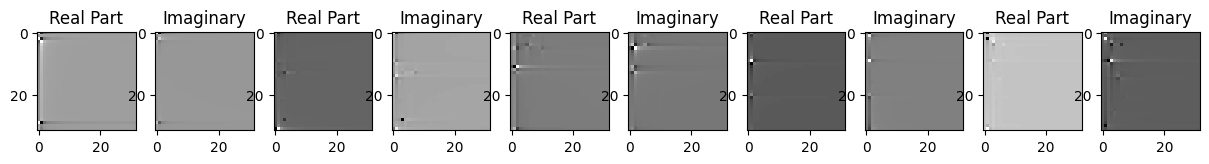

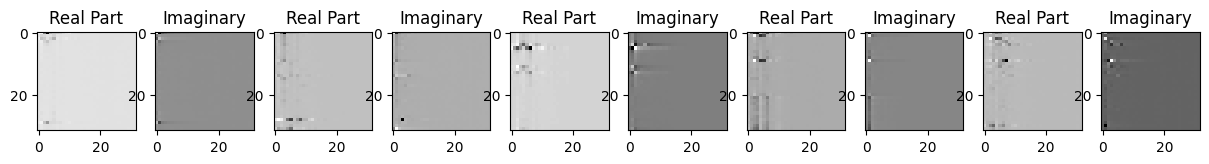

Epoch-54 lr: 0.001
Validation MSE Loss: 0.00024310241860803217
In indoor environment
When dimension is 256
NMSE is  -2.7070858920154905
Correlation is  0.6485379934310913


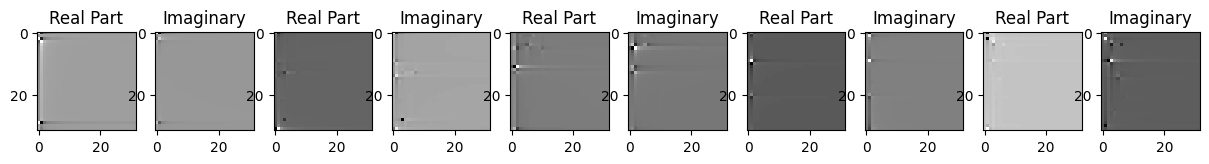

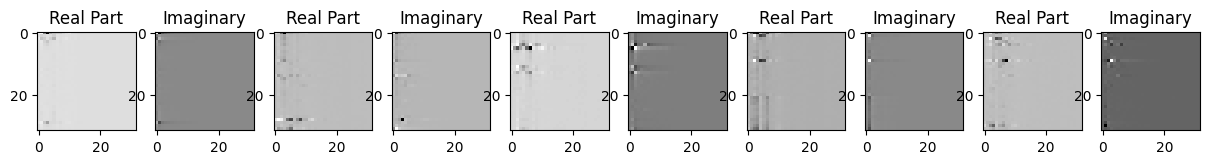

Epoch-55 lr: 0.001
Validation MSE Loss: 0.00024279049830511212
In indoor environment
When dimension is 256
NMSE is  -2.7129941483448485
Correlation is  0.6486934423446655


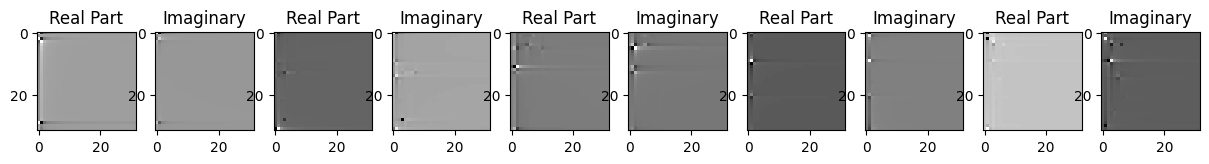

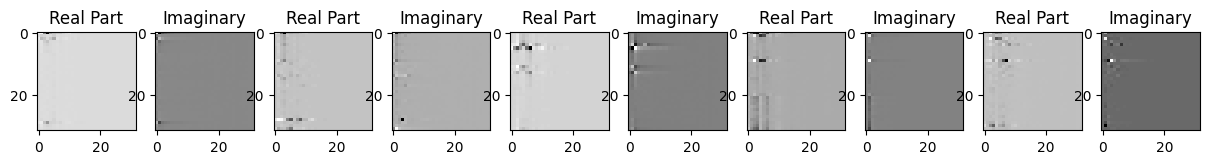

Epoch-56 lr: 0.001
Validation MSE Loss: 0.00024242300423793495
In indoor environment
When dimension is 256
NMSE is  -2.7179345716287733
Correlation is  0.6487090587615967


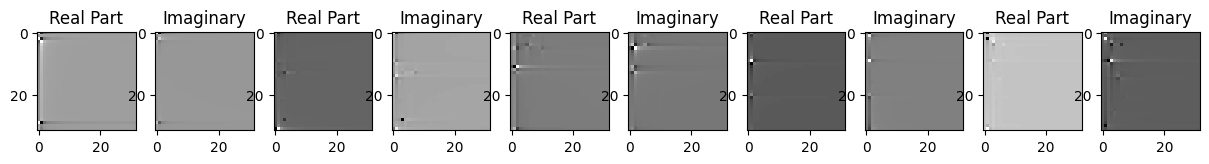

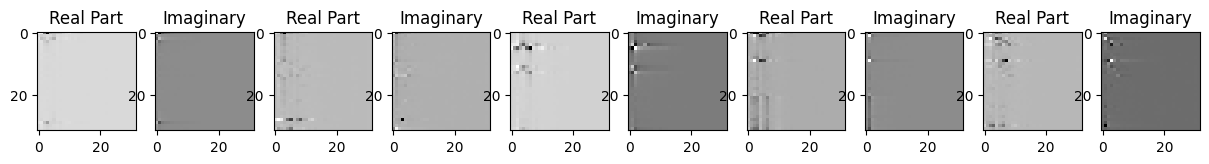

Epoch-57 lr: 0.001
Validation MSE Loss: 0.00024210828996729106
In indoor environment
When dimension is 256
NMSE is  -2.7225113982086455
Correlation is  0.6486372947692871


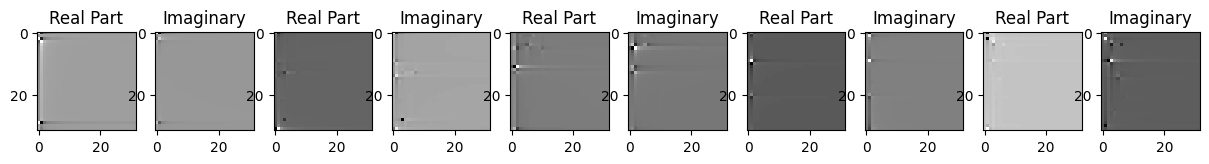

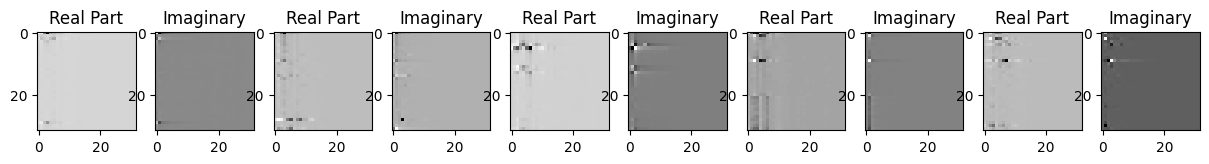

Epoch-58 lr: 0.001
Validation MSE Loss: 0.00024179663159884512
In indoor environment
When dimension is 256
NMSE is  -2.7284072137497652
Correlation is  0.6491732001304626


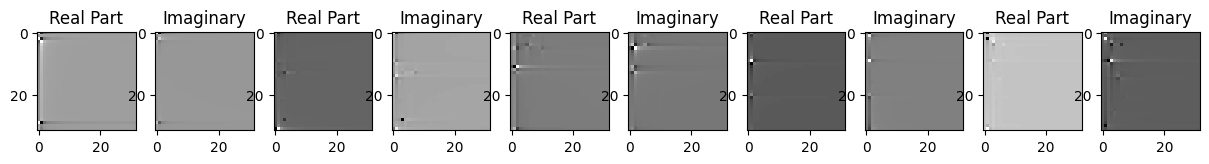

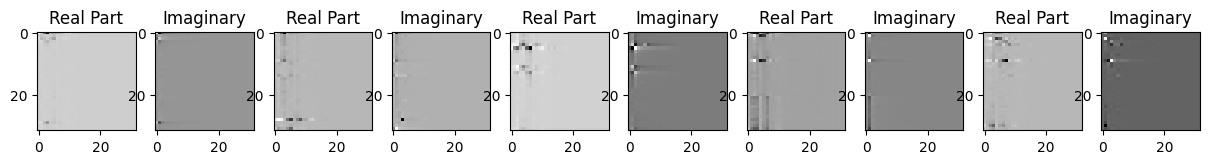

Epoch-59 lr: 0.001


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display
import math
import time
import itertools as it
import numpy as np
import torch

nmse_per_epoch = []  # Track NMSE for plotting

#epoch = 550
with torch.autograd.set_detect_anomaly(True):
    for epoch in range(n_epochs):
        print(f'Epoch-{epoch} lr: {optimizer.param_groups[0]["lr"]}')
        for i in range(total_batches):
            x_batch = x_train[i * batch_size:(i + 1) * batch_size]

            model.train()
            out = model(x_batch)
            loss = criterion(out, x_batch)
            train_loss_history.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        scheduler.step()

        # === Validation NMSE ===
        with torch.no_grad():
            model.eval()
            out = model(x_val)
            loss = criterion(out, x_val)
            print("Validation MSE Loss:", loss.item())
            val_loss_history.append(loss.item())

        # === Compute NMSE and Correlation ===
        with torch.no_grad():
            model.eval()
            x_hat = model(x_test)
            x_test = x_test.to(device)
            x_hat = x_hat.to(device)

            X_test = torch.reshape(X_test, (len(X_test), img_height, 125))
            x_test_real = torch.reshape(x_test[:, 0, :, :], (len(x_test), -1))
            x_test_imag = torch.reshape(x_test[:, 1, :, :], (len(x_test), -1))
            x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)
            x_hat_real = torch.reshape(x_hat[:, 0, :, :], (len(x_hat), -1))
            x_hat_imag = torch.reshape(x_hat[:, 1, :, :], (len(x_hat), -1))
            x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)
            x_hat_F = torch.reshape(x_hat_C, (len(x_hat_C), img_height, img_width))
            X_hat = torch.fft.fft(torch.cat((x_hat_F, torch.zeros((len(x_hat_C), img_height, 257 - img_width)).to(device)), axis=2), axis=2)
            X_hat = X_hat[:, :, 0:125]

            n1 = torch.sqrt(torch.sum(torch.conj(X_test) * X_test, axis=1)).to(device)
            n2 = torch.sqrt(torch.sum(torch.conj(X_hat) * X_hat, axis=1)).to(device)
            aa = abs(torch.sum(torch.conj(X_test.to(device)) * X_hat, axis=1).to(device)).to(device)
            rho = torch.mean(aa / (n1 * n2), axis=1).to(device)
            X_hat = torch.reshape(X_hat, (len(X_hat), -1))
            X_test = torch.reshape(X_test, (len(X_test), -1))
            power = torch.sum(abs(x_test_C) ** 2, axis=1).to(device)
            mse = torch.sum(abs(x_test_C - x_hat_C) ** 2, axis=1).to(device)
            NMSE = 10 * math.log10(torch.mean(mse / power))
            Correlation = torch.mean(rho).item().real

            print(f"In {envir} environment")
            print(f"When dimension is {encoded_dim}")
            print("NMSE is ", NMSE)
            print("Correlation is ", Correlation)

            nmse_per_epoch.append(NMSE)  # ✅ Store NMSE for plotting

        # === Save model every 50 epochs ===
        if epoch % 50 == 0:
            MODEL_PATH = Path("/kaggle/working/saved_model")
            MODEL_PATH.mkdir(parents=True, exist_ok=True)
            MODEL_NAME = f"CLLWCsiNet_model_{epoch}_{envir}_{encoded_dim}_1x.pth"
            MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
            print(f"Saving model to: {MODEL_SAVE_PATH}")
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'lr_state_dict': scheduler.state_dict()
            }, f=MODEL_SAVE_PATH)

        # === Inline and File Plot ===
        plot_dir = Path("/kaggle/working/plots")
        plot_dir.mkdir(exist_ok=True)
        plot_path = plot_dir / "nmse_vs_epoch.png"

        plt.figure(figsize=(10, 4))
        plt.plot(nmse_per_epoch, label="Validation NMSE (dB)", marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("NMSE (dB)")
        plt.title("NMSE vs Epoch")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close()

        if epoch % 10 == 0 or epoch == n_epochs - 1:
            display(Image(filename=plot_path))

        # === Sample visualizations every epoch ===
        with torch.no_grad():
            input = x_val[0:5, :, :, :]
            model.eval()
            out = model(input)
            CSI_img_ = out.cpu()

            fig, axs = plt.subplots(1, 10, figsize=(15, 8))
            for j, l in it.zip_longest(range(0, 5), range(1, 10, 2)):
                axs[j * 2].imshow(input[j, 0, :, :].cpu(), cmap='gist_gray')
                axs[j * 2].set_title('Real Part')
                axs[l].imshow(input[j, 1, :, :].cpu(), cmap='gist_gray')
                axs[l].set_title('Imaginary')
            plt.show()

            fig, axs = plt.subplots(1, 10, figsize=(15, 8))
            for i, x in it.zip_longest(range(0, 5), range(1, 10, 2)):
                axs[i * 2].imshow(CSI_img_[i, 0, :, :], cmap='gist_gray')
                axs[i * 2].set_title('Real Part')
                axs[x].imshow(CSI_img_[i, 1, :, :], cmap='gist_gray')
                axs[x].set_title('Imaginary')
            plt.show()

tEnd = time.time()
training_time = tEnd - tStart
print(f"It cost {training_time:.2f} sec for training.")
